# Lecture 7/ GV: Deep Models with PyTorch

## Quick cheat-sheet
- **Important:** use time-based splits; avoid random shuffling for financial data.
- **Labels:** Use `fret1d` (1-day forward return) or `fret5d` (5-day forward return) - these are **labels**, not features!

## Tasks for today's lecture:
* Introduction to neural networks and PyTorch
* Understanding activation functions and network architecture
* Building simple linear models as neural networks
* Adding regularization (Ridge/L2) to neural networks
* Applying models to financial data

## Topics to cover:
1. **Neural Network Basics**
   - Simple mapping examples
   - Common activation functions (visualization)
   - Understanding 1-layer and 2-layer networks (graphical illustration)

2. **Linear Models as Neural Networks**
   - Simple linear regression implemented as a 1-layer NN
   - Comparison with traditional linear regression

3. **Regularization in Neural Networks**
   - Ridge regression (L2 regularization) as a neural network
   - Understanding weight decay

4. **Application to Financial Data**
   - Using prepared features to predict returns
   - Training and evaluation

**Some useful info:**
* PyTorch documentation: https://pytorch.org/docs/stable/index.html
* PyTorch tutorials: https://pytorch.org/tutorials/
* Neural network basics: https://pytorch.org/tutorials/beginner/basics/intro.html

## Learning Flow Plan

### Part 1: Neural Network Basics
1. **Simple Mapping Example**
   - Create synthetic data: y = 2x + 1 + noise
   - Visualize the mapping
   - Show how a neural network can learn this relationship

2. **Activation Functions Visualization**
   - Plot common activations: ReLU, Sigmoid, Tanh, Linear
   - Show their properties and when to use them

3. **Network Architecture Visualization**
   - 1-layer network: input → linear → output (with diagram)
   - 2-layer network: input → linear → activation → linear → output (with diagram)
   - Show how data flows through each layer graphically

### Part 2: Linear Models as Neural Networks
4. **Simple Linear Regression as 1-Layer NN**
   - Implement y = Wx + b using PyTorch
   - Train on synthetic data
   - Compare with sklearn LinearRegression
   - Visualize learned weights

### Part 3: Regularization
5. **Ridge Regression as Neural Network**
   - Add L2 penalty (weight decay) to the linear model
   - Compare with sklearn Ridge
   - Show effect of different regularization strengths
   - Visualize how regularization affects weights

### Part 4: Application to Financial Data
6. **Prepare Financial Data**
   - Load features and returns
   - Create train/test split
   - Standardize features

7. **Train Linear Model on Financial Data**
   - Simple linear NN to predict returns
   - Evaluate performance
   - Compare with traditional regression

8. **Train Ridge Model on Financial Data**
   - Add regularization
   - Tune regularization parameter
   - Compare performance

---

**Implementation Strategy:**
- Keep functions minimal - most code in cells
- Use clear variable names
- Add visualizations at each step
- Compare NN implementations with sklearn equivalents
- Focus on understanding, not complexity

In [77]:
# after we install all the packages, import all of them for the use in today's lecture!
import platform
my_system = platform.uname()
print(f'My PC node: {my_system.node.lower()}')

# deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# storage and operations
import pandas as pd
import numpy as np
import datetime
from pathlib import Path
import joblib

# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# statistical analysis
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# set plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except OSError:
    try:
        plt.style.use('seaborn-darkgrid')
    except OSError:
        plt.style.use('dark_background')
sns.set_palette("husl")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print('Packages imported successfully!')
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

# Configuration and file paths
DATA_FROM_LIMIT = datetime.datetime(2015,1,1)

# we can specify some options depending on your computer
class Options:
    if my_system.node.lower() in ['mac','macbookpro-gv.local']: # GREG'S MACHINE - do not change please
        path = Path('../DataQT2026')
        wrds_name = 'gvfs'
        nasdaqlink_key = 'XXX'
    elif (my_system.node.lower() == 'huangyikaidemacbook-pro.local'):
        path = Path(r'/Users/huangyikai/Documents/FS SEM4/QT/')
        wrds_name = 'yi_kai'
        nasdaqlink_key = 'XXX'
        pass
print('Data Path: ',Options.path)

# some file names
class FileNames:
    fn_crsp = Options.path / 'crsp_original.parquet'
    fn_stock_features_labels = Options.path / 'stock_features.parquet'
    fn_option_features = Options.path / 'option_features_original.parquet'
    fn_ff_factors = Options.path / 'ff_factors.parquet'
    fn_sp500comp = Options.path / 'SP500_Index_Constitutes2024.csv'
    fn_universe = Options.path / 'permno_selection.csv'

My PC node: huangyikaidemacbook-pro.local
Packages imported successfully!
PyTorch version: 2.10.0
CUDA available: False
Data Path:  /Users/huangyikai/Documents/FS SEM4/QT


## Part 1: Neural Network Basics

### 1. Simple Function Example

**Terminology: Function vs Mapping**
- **Function (many-to-one):** Each input maps to exactly one output. Example: `y = 2x + 1` - for each x, there is exactly one y.
- **Mapping (many-to-many):** Inputs can map to multiple outputs. Example: Portfolio optimization where multiple weight vectors can be optimal.

**The Problem:** We have a **true underlying function** between inputs and outputs, but we only observe **noisy data**. Our goal is to **learn/discover the true function** from the noisy observations.

**Setup:**
- **True function:** `y = 2x + 1` (this is what we want to discover) - **This is a function** (each x → exactly one y)
- **Observed data:** We generate synthetic data by adding noise to the true relationship
- **Challenge:** Given only the noisy data points, can we learn the true function `y = 2x + 1`?

This is exactly what neural networks do: they learn functions from input to output by observing examples, even when the data is noisy. In the next sections, we'll use a neural network to learn this relationship from the noisy data.

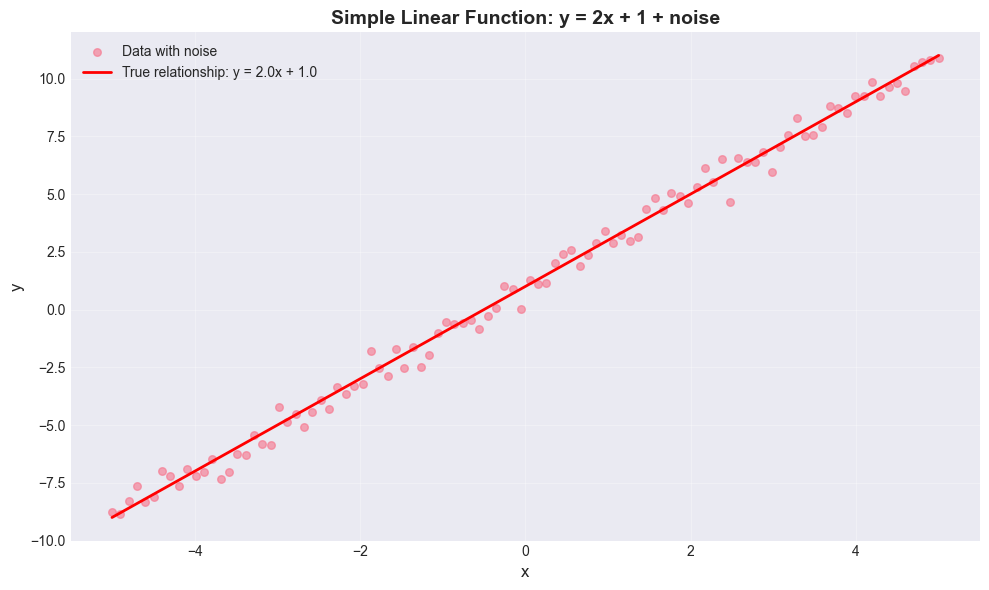

Data shape: X = (100, 1), y = (100, 1)
True parameters: slope = 2.0, intercept = 1.0

Learning Goal: Given only the noisy data points (blue dots),
              can a neural network learn the true relationship (red line)?
              We'll train a network to approximate: y ≈ 2.0x + 1.0


In [78]:
# Create synthetic data to demonstrate the learning problem
# True function: y = 2x + 1 (we know this, but the neural network doesn't!)
# This is a FUNCTION: each input x maps to exactly one output y
# We'll add noise to simulate real-world data, then train a network to discover the true function

# Generate input data
n_samples = 100
x = np.linspace(-5, 5, n_samples).reshape(-1, 1)

# True relationship: y = 2x + 1
true_slope = 2.0
true_intercept = 1.0
y_true = true_slope * x + true_intercept

# Add noise to make it realistic
noise = np.random.normal(0, 0.5, size=x.shape)
y = y_true + noise

# Visualize the data
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.6, label='Data with noise', s=30)
plt.plot(x, y_true, 'r-', linewidth=2, label=f'True relationship: y = {true_slope}x + {true_intercept}')
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Simple Linear Function: y = 2x + 1 + noise', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Data shape: X = {x.shape}, y = {y.shape}")
print(f"True parameters: slope = {true_slope}, intercept = {true_intercept}")
print(f"\nLearning Goal: Given only the noisy data points (blue dots),")
print(f"              can a neural network learn the true relationship (red line)?")
print(f"              We'll train a network to approximate: y ≈ {true_slope}x + {true_intercept}")

### 1b. Non-Linear Financial Example

Let's consider a financial example: predicting stock returns from characteristics. This is typically a **function** (many-to-one), but let's also discuss when it might be a **mapping** (many-to-many).

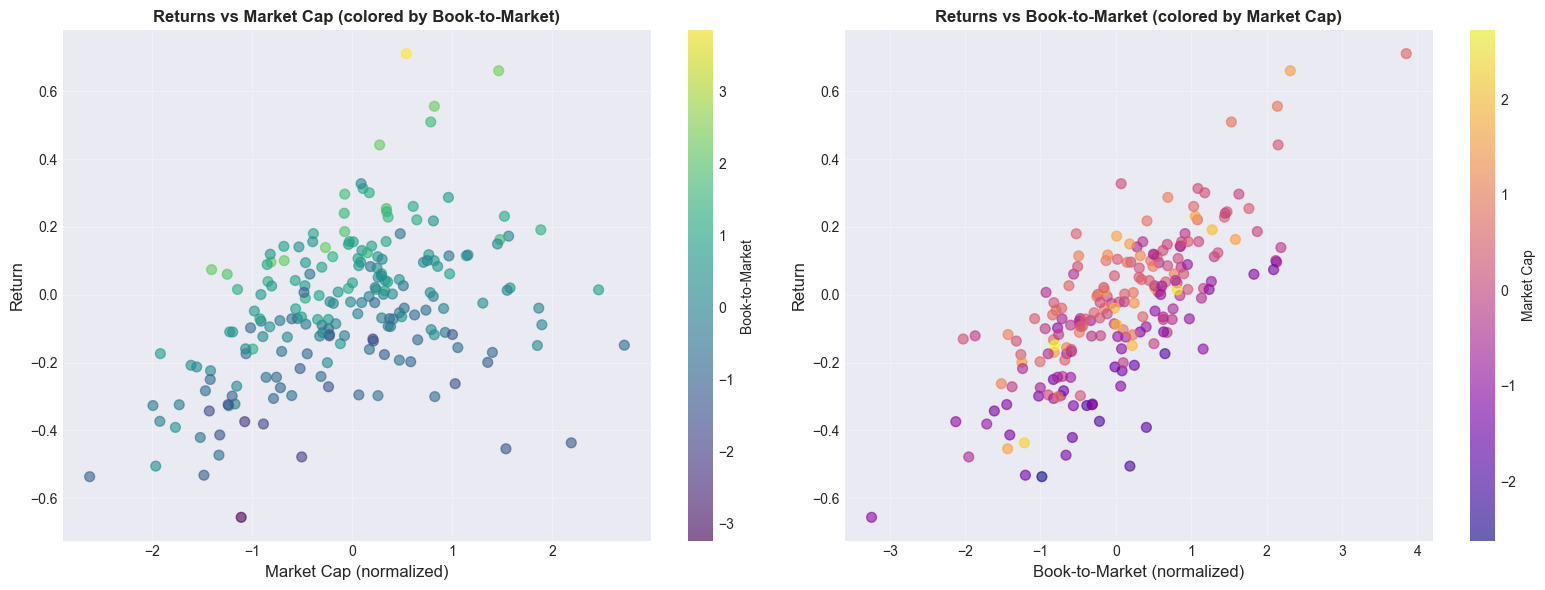

Function vs Mapping in Financial Context

This example: Characteristic → Return
  - Is this a FUNCTION or MAPPING?
  - Answer: FUNCTION (many-to-one)
  - Reason: For each combination of characteristics (market_cap, btm),
            there is exactly one predicted return value.

Alternative example: Characteristics → Optimal Portfolio Weights
  - Could be a FUNCTION: If we have a unique optimization solution
    (e.g., mean-variance with specific constraints)
  - Could be a MAPPING: If multiple portfolios are equally optimal
    (e.g., multiple solutions on the efficient frontier)

Most supervised learning (including neural networks) learns FUNCTIONS:
  - Input features → Single predicted output
  - Even when the true relationship is complex/non-linear


In [79]:
# Example: Non-linear relationship between stock characteristics and returns
# This simulates a realistic financial prediction problem

# Generate synthetic stock characteristics (e.g., market cap, book-to-market, momentum)
n_stocks = 200
np.random.seed(42)  # For reproducibility

# Characteristic 1: Market capitalization (log scale, normalized)
market_cap = np.random.normal(0, 1, n_stocks).reshape(-1, 1)

# Characteristic 2: Book-to-market ratio (normalized)
btm = np.random.normal(0, 1, n_stocks).reshape(-1, 1)

# True non-linear function: returns depend on both characteristics in a non-linear way
# Example: returns = 0.1 * market_cap - 0.05 * market_cap^2 + 0.15 * btm + 0.02 * market_cap * btm
# This is a FUNCTION: for each (market_cap, btm) pair, there is exactly one return
true_return = (0.1 * market_cap - 
               0.05 * market_cap**2 + 
               0.15 * btm + 
               0.02 * market_cap * btm)

# Add noise to simulate real-world uncertainty
noise = np.random.normal(0, 0.1, size=true_return.shape)
observed_return = true_return + noise

# Visualize the relationship
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Returns vs Market Cap (colored by BTM)
scatter1 = axes[0].scatter(market_cap, observed_return, c=btm.flatten(), 
                          cmap='viridis', alpha=0.6, s=50)
axes[0].set_xlabel('Market Cap (normalized)', fontsize=12)
axes[0].set_ylabel('Return', fontsize=12)
axes[0].set_title('Returns vs Market Cap (colored by Book-to-Market)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Book-to-Market')

# Plot 2: Returns vs Book-to-Market (colored by Market Cap)
scatter2 = axes[1].scatter(btm, observed_return, c=market_cap.flatten(), 
                          cmap='plasma', alpha=0.6, s=50)
axes[1].set_xlabel('Book-to-Market (normalized)', fontsize=12)
axes[1].set_ylabel('Return', fontsize=12)
axes[1].set_title('Returns vs Book-to-Market (colored by Market Cap)', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Market Cap')

plt.tight_layout()
plt.show()

print("=" * 70)
print("Function vs Mapping in Financial Context")
print("=" * 70)
print("\nThis example: Characteristic → Return")
print("  - Is this a FUNCTION or MAPPING?")
print("  - Answer: FUNCTION (many-to-one)")
print("  - Reason: For each combination of characteristics (market_cap, btm),")
print("            there is exactly one predicted return value.")
print("\nAlternative example: Characteristics → Optimal Portfolio Weights")
print("  - Could be a FUNCTION: If we have a unique optimization solution")
print("    (e.g., mean-variance with specific constraints)")
print("  - Could be a MAPPING: If multiple portfolios are equally optimal")
print("    (e.g., multiple solutions on the efficient frontier)")
print("\nMost supervised learning (including neural networks) learns FUNCTIONS:")
print("  - Input features → Single predicted output")
print("  - Even when the true relationship is complex/non-linear")
print("=" * 70)

### 2. Network Architecture Visualization

Let's visualize how data flows through neural networks. We'll show 1-layer and 2-layer networks with example computations.




Network Architecture Explanation:
1-Layer Network: Input → Linear Transformation → Output
  - Simple linear regression: y = Wx + b
  - W = weight matrix, b = bias vector

2-Layer Network: Input → Linear → Activation → Linear → Output
  - First layer: z = W1x + b1 (linear transformation)
  - Activation: a = θ(z) (non-linear activation function)
  - Second layer: ŷ = W2a + b2 (linear transformation)
  - The activation function introduces non-linearity, allowing the network to learn complex patterns
  
<img src="../DataQT2026/network_architecture.png" alt="Network Architecture" style="width:100%;">

In [80]:
# Example: How data flows through networks with actual numbers
print("=" * 70)
print("Example: Data Flow Through Networks")
print("=" * 70)

# Example input
x_example = np.array([[2.0]])  # Single input value
print(f"\nInput: x = {x_example[0, 0]}")

# 1-Layer Network Example
print("\n" + "-" * 70)
print("1-Layer Network (Linear Regression)")
print("-" * 70)
W1 = np.array([[1.5]])  # Weight
b1 = np.array([0.5])    # Bias
y_hat_1layer = W1 @ x_example + b1
print(f"Weight W = {W1[0, 0]}, Bias b = {b1[0]}")
print(f"Output: ŷ = W·x + b = {W1[0, 0]} × {x_example[0, 0]} + {b1[0]} = {y_hat_1layer[0, 0]:.2f}")

# 2-Layer Network Example
print("\n" + "-" * 70)
print("2-Layer Network (with ReLU activation)")
print("-" * 70)
W1_2layer = np.array([[1.2]])  # First layer weight
b1_2layer = np.array([-0.5])   # First layer bias
W2_2layer = np.array([[0.8]])  # Second layer weight
b2_2layer = np.array([0.3])    # Second layer bias

# First layer
z = W1_2layer @ x_example + b1_2layer
print(f"Layer 1 - Weight W1 = {W1_2layer[0, 0]}, Bias b1 = {b1_2layer[0]}")
print(f"  z = W1·x + b1 = {W1_2layer[0, 0]} × {x_example[0, 0]} + {b1_2layer[0]} = {z[0, 0]:.2f}")

# Activation (ReLU)
a = np.maximum(0, z)
print(f"Activation (ReLU): a = max(0, z) = max(0, {z[0, 0]:.2f}) = {a[0, 0]:.2f}")

# Second layer
y_hat_2layer = W2_2layer @ a + b2_2layer
print(f"Layer 2 - Weight W2 = {W2_2layer[0, 0]}, Bias b2 = {b2_2layer[0]}")
print(f"  ŷ = W2·a + b2 = {W2_2layer[0, 0]} × {a[0, 0]:.2f} + {b2_2layer[0]} = {y_hat_2layer[0, 0]:.2f}")

print("\n" + "=" * 70)
print("Key Insight: The activation function (ReLU) introduces non-linearity.")
print("Without it, multiple linear layers would just collapse into a single linear layer!")
print("=" * 70)

Example: Data Flow Through Networks

Input: x = 2.0

----------------------------------------------------------------------
1-Layer Network (Linear Regression)
----------------------------------------------------------------------
Weight W = 1.5, Bias b = 0.5
Output: ŷ = W·x + b = 1.5 × 2.0 + 0.5 = 3.50

----------------------------------------------------------------------
2-Layer Network (with ReLU activation)
----------------------------------------------------------------------
Layer 1 - Weight W1 = 1.2, Bias b1 = -0.5
  z = W1·x + b1 = 1.2 × 2.0 + -0.5 = 1.90
Activation (ReLU): a = max(0, z) = max(0, 1.90) = 1.90
Layer 2 - Weight W2 = 0.8, Bias b2 = 0.3
  ŷ = W2·a + b2 = 0.8 × 1.90 + 0.3 = 1.82

Key Insight: The activation function (ReLU) introduces non-linearity.
Without it, multiple linear layers would just collapse into a single linear layer!


### 3. Activation Functions Visualization

Activation functions introduce non-linearity into neural networks. Let's visualize the most common ones.

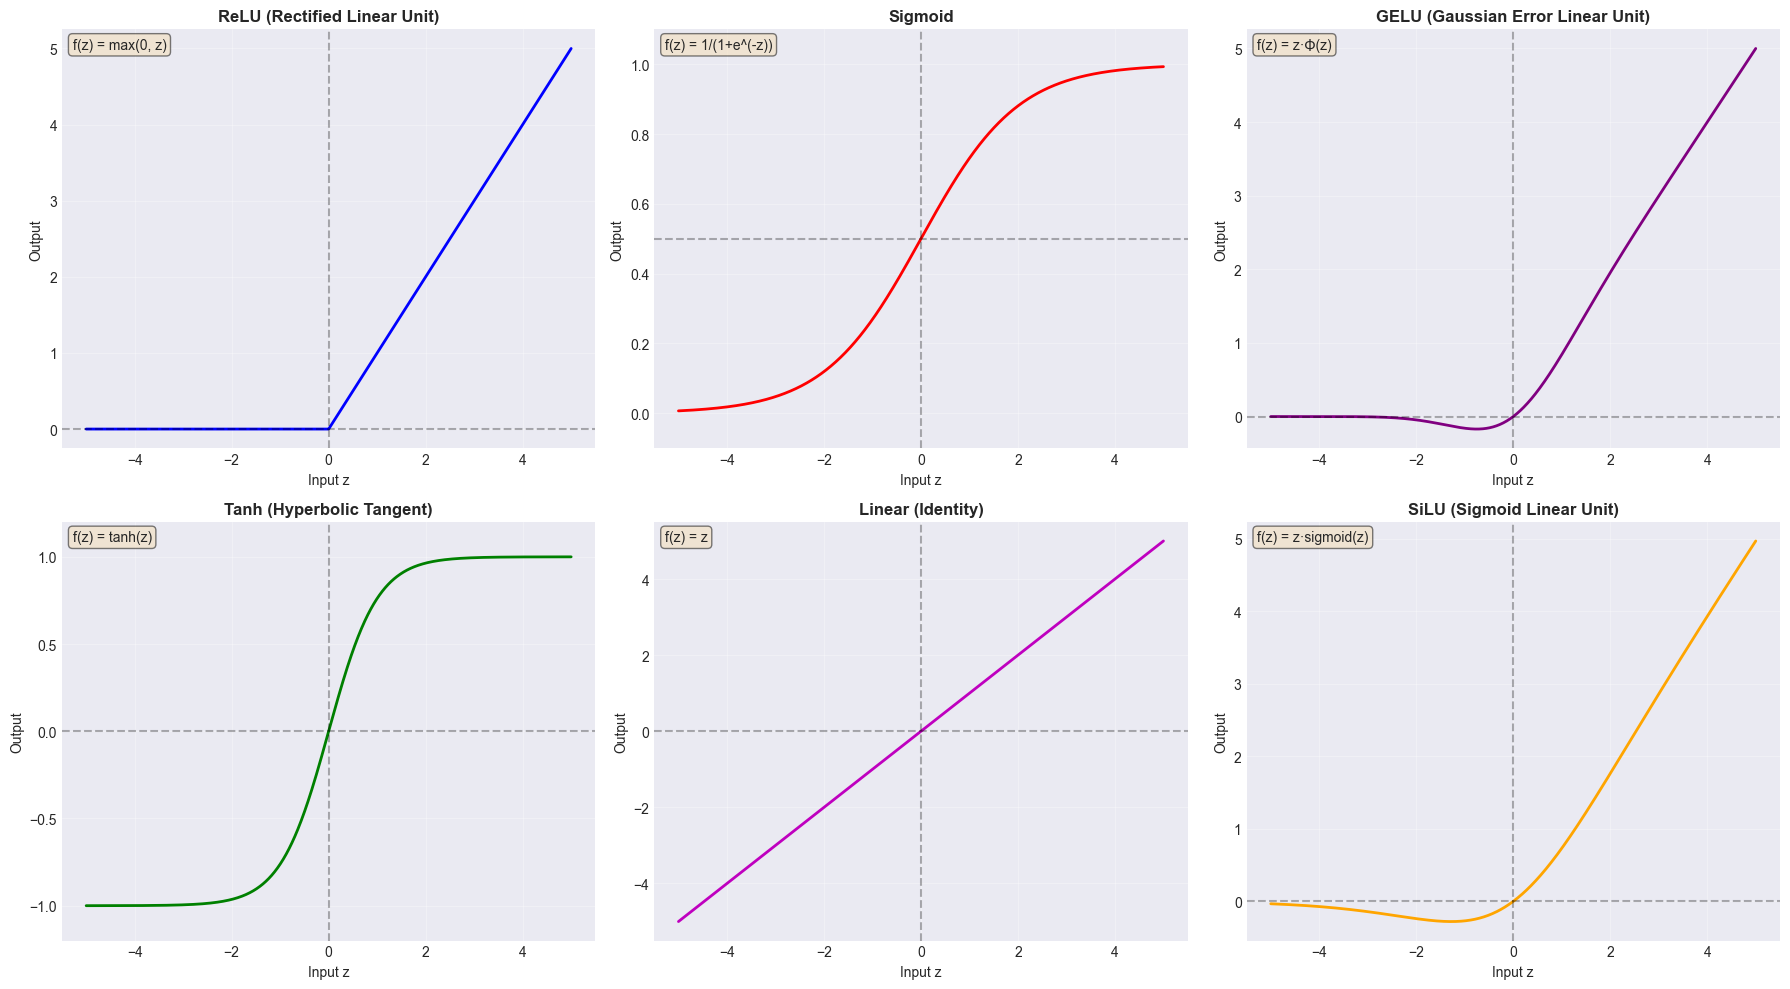


Activation Function Properties:
- ReLU: Outputs 0 for negative inputs, linear for positive. Most common in hidden layers.
- Sigmoid: Outputs between 0 and 1. Good for binary classification (output layer).
- GELU: Smooth activation used in transformers (BERT, GPT). z * Φ(z) where Φ is Gaussian CDF.
- Tanh: Outputs between -1 and 1. Similar to sigmoid but centered at 0.
- Linear: No transformation. Used in regression output layers.
- SiLU: Smooth, non-monotonic activation. z * sigmoid(z). Often performs better than ReLU.


In [81]:
# Visualize common activation functions
z = np.linspace(-5, 5, 1000)

# Define activation functions
relu = np.maximum(0, z)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
linear = z
silu = z * sigmoid  # SiLU: x * sigmoid(x)
# GELU: Gaussian Error Linear Unit (used in transformers like BERT, GPT)
# Approximation: x * 0.5 * (1 + tanh(sqrt(2/pi) * (x + 0.044715 * x^3)))
gelu = z * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

# Create subplots (2 rows, 3 columns for 5 functions)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ReLU
axes[0, 0].plot(z, relu, 'b-', linewidth=2)
axes[0, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0, 0].set_title('ReLU (Rectified Linear Unit)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Input z', fontsize=10)
axes[0, 0].set_ylabel('Output', fontsize=10)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(0.02, 0.98, 'f(z) = max(0, z)', transform=axes[0, 0].transAxes, 
                verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Sigmoid
axes[0, 1].plot(z, sigmoid, 'r-', linewidth=2)
axes[0, 1].axhline(y=0.5, color='k', linestyle='--', alpha=0.3)
axes[0, 1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0, 1].set_title('Sigmoid', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Input z', fontsize=10)
axes[0, 1].set_ylabel('Output', fontsize=10)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].text(0.02, 0.98, 'f(z) = 1/(1+e^(-z))', transform=axes[0, 1].transAxes, 
                verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[0, 1].set_ylim(-0.1, 1.1)

# GELU (Gaussian Error Linear Unit)
axes[0, 2].plot(z, gelu, 'purple', linewidth=2)
axes[0, 2].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0, 2].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[0, 2].set_title('GELU (Gaussian Error Linear Unit)', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Input z', fontsize=10)
axes[0, 2].set_ylabel('Output', fontsize=10)
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].text(0.02, 0.98, 'f(z) = z·Φ(z)', transform=axes[0, 2].transAxes, 
                verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Tanh
axes[1, 0].plot(z, tanh, 'g-', linewidth=2)
axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1, 0].set_title('Tanh (Hyperbolic Tangent)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Input z', fontsize=10)
axes[1, 0].set_ylabel('Output', fontsize=10)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].text(0.02, 0.98, 'f(z) = tanh(z)', transform=axes[1, 0].transAxes, 
                verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].set_ylim(-1.2, 1.2)

# Linear (Identity)
axes[1, 1].plot(z, linear, 'm-', linewidth=2)
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1, 1].set_title('Linear (Identity)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Input z', fontsize=10)
axes[1, 1].set_ylabel('Output', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].text(0.02, 0.98, 'f(z) = z', transform=axes[1, 1].transAxes, 
                verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# SiLU (Sigmoid Linear Unit / Swish)
axes[1, 2].plot(z, silu, 'orange', linewidth=2)
axes[1, 2].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[1, 2].axvline(x=0, color='k', linestyle='--', alpha=0.3)
axes[1, 2].set_title('SiLU (Sigmoid Linear Unit)', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Input z', fontsize=10)
axes[1, 2].set_ylabel('Output', fontsize=10)
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].text(0.02, 0.98, 'f(z) = z·sigmoid(z)', transform=axes[1, 2].transAxes, 
                verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("\nActivation Function Properties:")
print("- ReLU: Outputs 0 for negative inputs, linear for positive. Most common in hidden layers.")
print("- Sigmoid: Outputs between 0 and 1. Good for binary classification (output layer).")
print("- GELU: Smooth activation used in transformers (BERT, GPT). z * Φ(z) where Φ is Gaussian CDF.")
print("- Tanh: Outputs between -1 and 1. Similar to sigmoid but centered at 0.")
print("- Linear: No transformation. Used in regression output layers.")
print("- SiLU: Smooth, non-monotonic activation. z * sigmoid(z). Often performs better than ReLU.")

---

**Part 1 Summary:**
- ✅ Created synthetic linear data to understand the mapping problem
- ✅ Illustrated 1-layer and 2-layer network architectures
- ✅ Demonstrated how data flows through networks with example computations
- ✅ Visualized common activation functions (ReLU, Sigmoid, GELU, Tanh, Linear, SiLU)

**Next:** In Part 2, we'll implement these concepts using PyTorch to build actual neural networks!

## Part 2: Linear Models as Neural Networks

### 4. Simple Linear Regression as 1-Layer Neural Network

Now we'll implement linear regression using PyTorch. A 1-layer neural network with no activation function is exactly equivalent to linear regression: `y = Wx + b`.

We'll:
1. Build a simple linear neural network in PyTorch
2. Train it on our synthetic data from Part 1
3. Compare with sklearn's LinearRegression
4. Visualize the learned weights

In [82]:
# Convert data to PyTorch tensors
# Use the synthetic data from Part 1 (x, y)
X_tensor = torch.FloatTensor(x)
y_tensor = torch.FloatTensor(y)

print(f"Data shapes: X = {X_tensor.shape}, y = {y_tensor.shape}")
print(f"Input dimension: {X_tensor.shape[1]}, Output dimension: {y_tensor.shape[1]}")

# Define a simple 1-layer neural network (linear regression)
# nn.Linear(input_size, output_size) implements: output = input @ weight^T + bias
linear_model = nn.Linear(in_features=1, out_features=1)

# Initialize weights (optional - PyTorch initializes randomly by default)
# But let's see what they are initially
print(f"\nInitial weights:")
print(f"  Weight (W): {linear_model.weight.data.item():.4f}")
print(f"  Bias (b): {linear_model.bias.data.item():.4f}")

# Define loss function (Mean Squared Error)
criterion = nn.MSELoss()

# Define optimizer (Adam - Adaptive Moment Estimation)
# Adam is the standard optimizer for neural networks because it:
# - Adapts learning rate per parameter
# - Uses momentum to smooth gradients
# - Generally converges faster and more reliably than SGD
learning_rate = 0.01
optimizer = optim.Adam(linear_model.parameters(), lr=learning_rate)

# Training loop
# Adam typically converges faster than SGD, so we can use fewer epochs
n_epochs = 500
losses = []

print(f"\nTraining for {n_epochs} epochs...")
for epoch in range(n_epochs):
    # Forward pass: compute predictions
    y_pred = linear_model(X_tensor)
    
    # Compute loss
    loss = criterion(y_pred, y_tensor)
    
    # Backward pass: compute gradients
    optimizer.zero_grad()  # Clear previous gradients
    loss.backward()        # Compute gradients
    
    # Update weights
    optimizer.step()
    
    # Store loss for visualization
    losses.append(loss.item())
    
    # Print progress every 100 epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.6f}")

# Get learned parameters
learned_weight = linear_model.weight.data.item()
learned_bias = linear_model.bias.data.item()

print(f"\n" + "=" * 70)
print("Training Complete!")
print("=" * 70)
print(f"Learned parameters:")
print(f"  Weight (W): {learned_weight:.4f} (True: {true_slope:.4f})")
print(f"  Bias (b): {learned_bias:.4f} (True: {true_intercept:.4f})")
print(f"\nError:")
print(f"  Weight error: {abs(learned_weight - true_slope):.4f}")
print(f"  Bias error: {abs(learned_bias - true_intercept):.4f}")

Data shapes: X = torch.Size([100, 1]), y = torch.Size([100, 1])
Input dimension: 1, Output dimension: 1

Initial weights:
  Weight (W): 0.7645
  Bias (b): 0.8300

Training for 500 epochs...
Epoch [100/500], Loss: 1.707487
Epoch [200/500], Loss: 0.251532
Epoch [300/500], Loss: 0.204069
Epoch [400/500], Loss: 0.203727
Epoch [500/500], Loss: 0.203726

Training Complete!
Learned parameters:
  Weight (W): 2.0069 (True: 2.0000)
  Bias (b): 0.9481 (True: 1.0000)

Error:
  Weight error: 0.0069
  Bias error: 0.0519


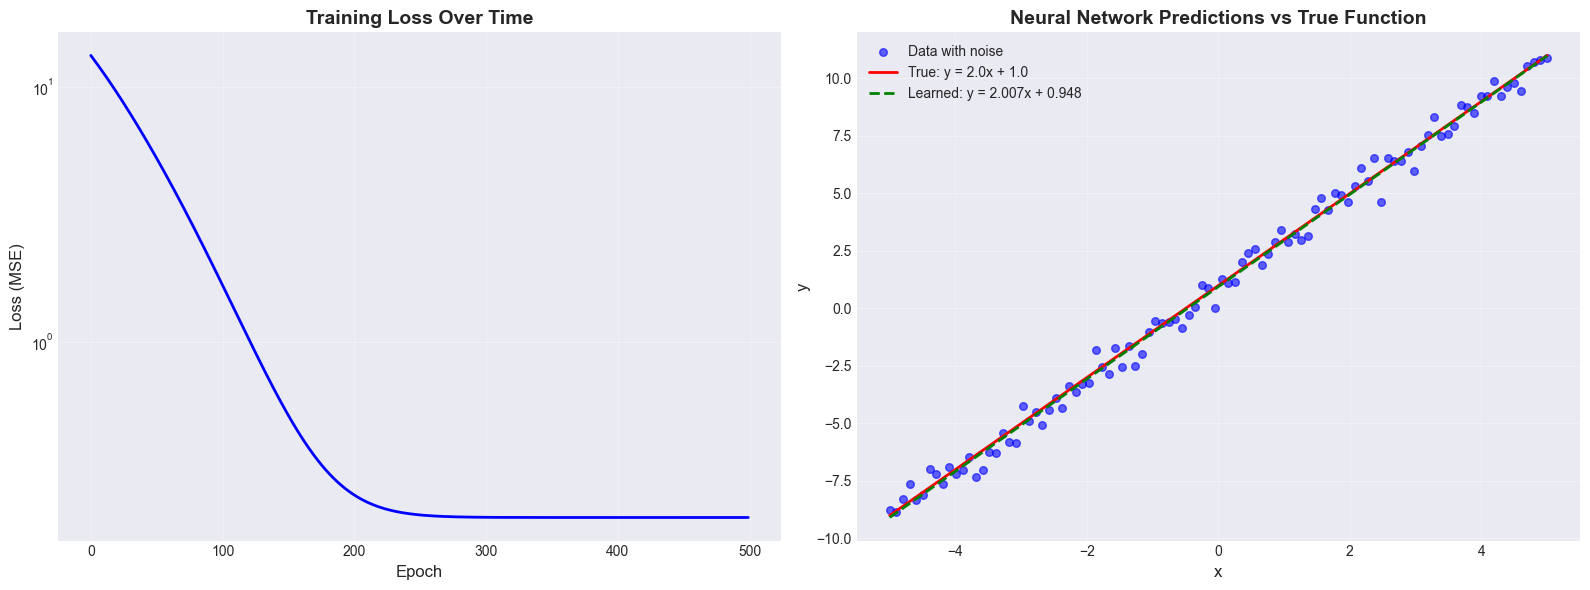


Final training loss: 0.203726


In [83]:
# Visualize training progress and predictions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Training loss over epochs
axes[0].plot(losses, 'b-', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training Loss Over Time', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')  # Log scale to see the decrease better

# Plot 2: Data and predictions
# Get predictions from the trained model
with torch.no_grad():  # No need to compute gradients for inference
    y_pred_tensor = linear_model(X_tensor)
    y_pred_np = y_pred_tensor.numpy()

axes[1].scatter(x, y, alpha=0.6, label='Data with noise', s=30, color='blue')
axes[1].plot(x, y_true, 'r-', linewidth=2, label=f'True: y = {true_slope}x + {true_intercept}')
axes[1].plot(x, y_pred_np, 'g--', linewidth=2, 
            label=f'Learned: y = {learned_weight:.3f}x + {learned_bias:.3f}')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Neural Network Predictions vs True Function', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal training loss: {losses[-1]:.6f}")

In [84]:
# Compare with sklearn LinearRegression
print("=" * 70)
print("Comparison: PyTorch Neural Network vs sklearn LinearRegression")
print("=" * 70)

# Fit sklearn model
sklearn_model = LinearRegression()
sklearn_model.fit(x, y)

sklearn_weight = sklearn_model.coef_[0, 0]
sklearn_bias = sklearn_model.intercept_[0]

print(f"\nPyTorch Neural Network:")
print(f"  Weight (W): {learned_weight:.6f}")
print(f"  Bias (b): {learned_bias:.6f}")

print(f"\nsklearn LinearRegression:")
print(f"  Weight (W): {sklearn_weight:.6f}")
print(f"  Bias (b): {sklearn_bias:.6f}")

print(f"\nDifference:")
print(f"  Weight difference: {abs(learned_weight - sklearn_weight):.6f}")
print(f"  Bias difference: {abs(learned_bias - sklearn_bias):.6f}")

# Compute predictions from sklearn
y_pred_sklearn = sklearn_model.predict(x)

# Compare predictions
mse_pytorch = mean_squared_error(y, y_pred_np)
mse_sklearn = mean_squared_error(y, y_pred_sklearn)

print(f"\nMean Squared Error:")
print(f"  PyTorch: {mse_pytorch:.6f}")
print(f"  sklearn: {mse_sklearn:.6f}")
print(f"  Difference: {abs(mse_pytorch - mse_sklearn):.6f}")

print(f"\n" + "=" * 70)
print("Key Insight: A 1-layer neural network with no activation function")
print("is mathematically equivalent to linear regression!")
print("Both learn the same function: y = Wx + b")
print("=" * 70)

Comparison: PyTorch Neural Network vs sklearn LinearRegression

PyTorch Neural Network:
  Weight (W): 2.006895
  Bias (b): 0.948077

sklearn LinearRegression:
  Weight (W): 2.006897
  Bias (b): 0.948077

Difference:
  Weight difference: 0.000001
  Bias difference: 0.000000

Mean Squared Error:
  PyTorch: 0.203726
  sklearn: 0.203726
  Difference: 0.000000

Key Insight: A 1-layer neural network with no activation function
is mathematically equivalent to linear regression!
Both learn the same function: y = Wx + b


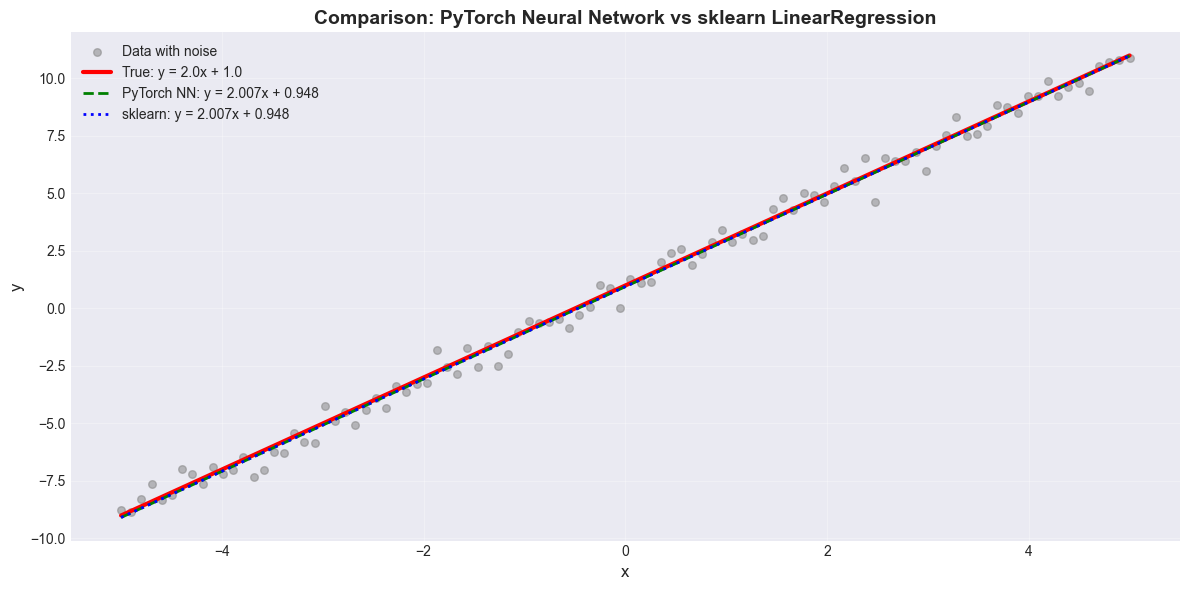


Note: The PyTorch and sklearn lines should be nearly identical!
Small differences may occur due to:
  - Different optimization algorithms (Adam/iterative vs analytical solution)
  - Numerical precision
  - Convergence tolerance


In [85]:
# Visualize both models together
plt.figure(figsize=(12, 6))
plt.scatter(x, y, alpha=0.5, label='Data with noise', s=30, color='gray', zorder=1)
plt.plot(x, y_true, 'r-', linewidth=3, label=f'True: y = {true_slope}x + {true_intercept}', zorder=2)
plt.plot(x, y_pred_np, 'g--', linewidth=2, label=f'PyTorch NN: y = {learned_weight:.3f}x + {learned_bias:.3f}', zorder=3)
plt.plot(x, y_pred_sklearn, 'b:', linewidth=2, label=f'sklearn: y = {sklearn_weight:.3f}x + {sklearn_bias:.3f}', zorder=3)
plt.xlabel('x', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Comparison: PyTorch Neural Network vs sklearn LinearRegression', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nNote: The PyTorch and sklearn lines should be nearly identical!")
print("Small differences may occur due to:")
print("  - Different optimization algorithms (Adam/iterative vs analytical solution)")
print("  - Numerical precision")
print("  - Convergence tolerance")

### 4b. What Happens if We Use Activation Functions on Linear Data?

**Question:** If the true relationship is linear (`y = 2x + 1`), what happens if we add a non-linear activation function?

Let's test this with ReLU and Sigmoid activations to see how they behave.

Linear (no activation): Final loss = 0.211810
Linear + ReLU: Final loss = 12.907619
Linear + Sigmoid: Final loss = 30.014072


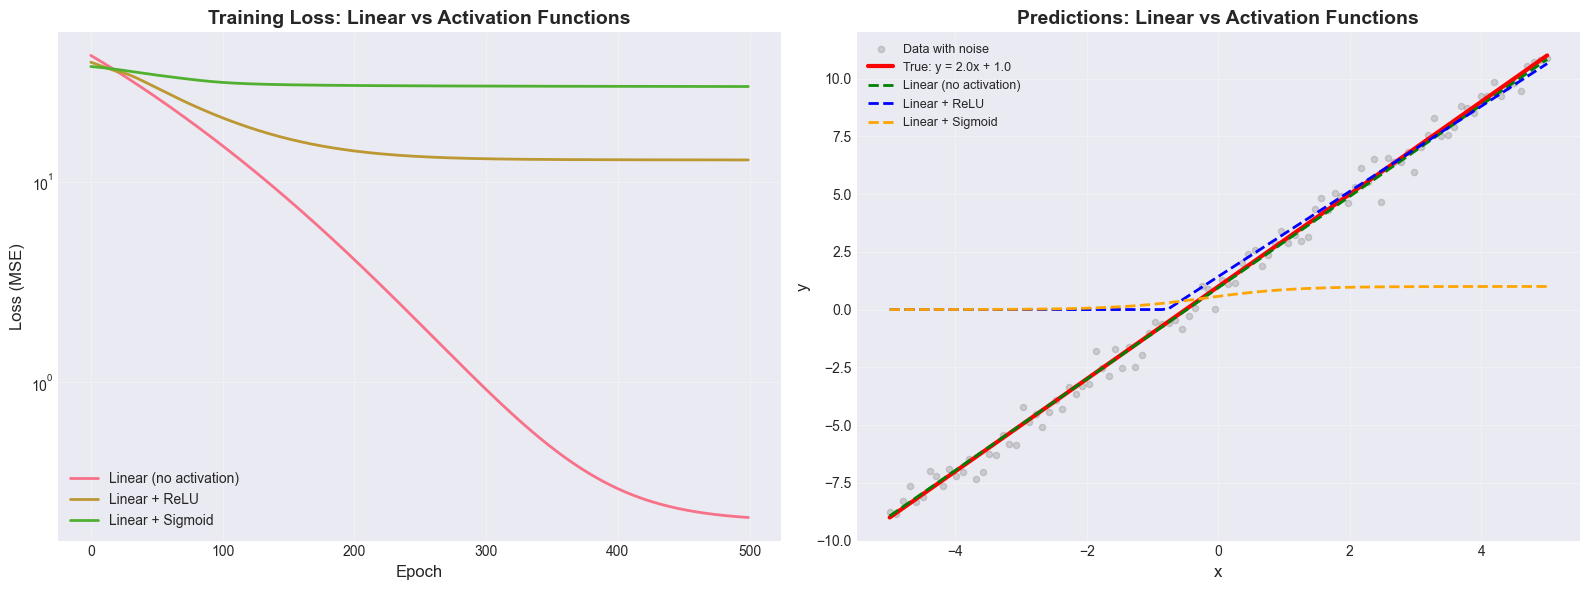


Analysis: Activation Functions on Linear Data

1. Linear (no activation):
   - Can learn the true linear function perfectly
   - Most efficient for linear relationships

2. Linear + ReLU:
   - ReLU is linear for positive inputs: ReLU(z) = z if z > 0
   - Can approximate linear functions by keeping inputs positive
   - May need bias adjustment to shift inputs into positive range
   - Final loss: 12.907619

3. Linear + Sigmoid:
   - Sigmoid is non-linear and bounded [0, 1]
   - Cannot represent unbounded linear relationships well
   - Saturates at extremes, limiting range of outputs
   - Final loss: 30.014072

Key Insight: For linear data, activation functions are unnecessary
and can make learning harder. Use them only when you need non-linearity!


In [86]:
# Test: What happens when we use activation functions on linear data?

# Model 1: Linear (no activation) - our baseline
model_linear = nn.Sequential(
    nn.Linear(1, 1)
)

# Model 2: Linear + ReLU activation
model_relu = nn.Sequential(
    nn.Linear(1, 1),
    nn.ReLU()
)

# Model 3: Linear + Sigmoid activation
model_sigmoid = nn.Sequential(
    nn.Linear(1, 1),
    nn.Sigmoid()
)

models = {
    'Linear (no activation)': model_linear,
    'Linear + ReLU': model_relu,
    'Linear + Sigmoid': model_sigmoid
}

# Train all models
results = {}
criterion = nn.MSELoss()
n_epochs = 500

for name, model in models.items():
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    model_losses = []
    
    for epoch in range(n_epochs):
        y_pred = model(X_tensor)
        loss = criterion(y_pred, y_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        model_losses.append(loss.item())
    
    # Get predictions
    with torch.no_grad():
        y_pred_model = model(X_tensor).numpy()
    
    results[name] = {
        'model': model,
        'losses': model_losses,
        'predictions': y_pred_model,
        'final_loss': model_losses[-1]
    }
    
    print(f"{name}: Final loss = {model_losses[-1]:.6f}")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Training losses
for name, result in results.items():
    axes[0].plot(result['losses'], label=name, linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss (MSE)', fontsize=12)
axes[0].set_title('Training Loss: Linear vs Activation Functions', fontsize=14, fontweight='bold')
axes[0].set_yscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Predictions
axes[1].scatter(x, y, alpha=0.3, label='Data with noise', s=20, color='gray', zorder=1)
axes[1].plot(x, y_true, 'r-', linewidth=3, label=f'True: y = {true_slope}x + {true_intercept}', zorder=2)

colors = {'Linear (no activation)': 'green', 'Linear + ReLU': 'blue', 'Linear + Sigmoid': 'orange'}
for name, result in results.items():
    axes[1].plot(x, result['predictions'], '--', linewidth=2, 
                label=name, color=colors.get(name, 'black'), zorder=3)

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title('Predictions: Linear vs Activation Functions', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Analysis
print("\n" + "=" * 70)
print("Analysis: Activation Functions on Linear Data")
print("=" * 70)
print("\n1. Linear (no activation):")
print("   - Can learn the true linear function perfectly")
print("   - Most efficient for linear relationships")

print("\n2. Linear + ReLU:")
print("   - ReLU is linear for positive inputs: ReLU(z) = z if z > 0")
print("   - Can approximate linear functions by keeping inputs positive")
print("   - May need bias adjustment to shift inputs into positive range")
print(f"   - Final loss: {results['Linear + ReLU']['final_loss']:.6f}")

print("\n3. Linear + Sigmoid:")
print("   - Sigmoid is non-linear and bounded [0, 1]")
print("   - Cannot represent unbounded linear relationships well")
print("   - Saturates at extremes, limiting range of outputs")
print(f"   - Final loss: {results['Linear + Sigmoid']['final_loss']:.6f}")

print("\n" + "=" * 70)
print("Key Insight: For linear data, activation functions are unnecessary")
print("and can make learning harder. Use them only when you need non-linearity!")
print("=" * 70)

---

**Part 2 Summary:**
- ✅ Implemented linear regression as a 1-layer neural network using PyTorch
- ✅ Trained the model using Adam optimizer (standard for neural networks)
- ✅ Compared with sklearn LinearRegression - they learn the same function!
- ✅ Visualized training progress and learned parameters

**Key Takeaways:**
- A 1-layer neural network with no activation function = Linear Regression
- PyTorch uses iterative optimization (Adam with adaptive learning rates)
- sklearn uses analytical solution (closed-form)
- Both methods learn: `y = Wx + b`
- Neural networks are just a flexible framework - we can build simple models too!
- **Adam optimizer**: Adapts learning rate per parameter, uses momentum, converges faster than SGD

**Next:** In Part 3, we'll add regularization (Ridge/L2) to prevent overfitting.

## Part 3: Regularization

### 5. Ridge Regression as Neural Network

**Regularization** helps prevent overfitting by penalizing large weights. Ridge regression adds an L2 penalty (sum of squared weights) to the loss function.

**Ridge Loss = MSE + λ × (sum of squared weights)**

In PyTorch, we can add L2 regularization using **weight decay** in the optimizer, or by manually adding the penalty to the loss function.

We'll:
1. Implement Ridge regression using weight decay in PyTorch
2. Compare with sklearn's Ridge
3. Test different regularization strengths (λ values)
4. Visualize how regularization affects the learned weights

In [87]:
# Ridge Regression using weight decay in PyTorch
# Weight decay in Adam/SGD is equivalent to L2 regularization

# Test different regularization strengths (alpha in sklearn = weight_decay in PyTorch)
regularization_strengths = [0.0, 0.01, 0.1, 1.0, 10.0]  # lambda values

ridge_results = {}

print("=" * 70)
print("Training Ridge Regression Models with Different Regularization Strengths")
print("=" * 70)

for alpha in regularization_strengths:
    # Create a fresh model for each regularization strength
    model = nn.Linear(1, 1)
    
    # Weight decay parameter: in PyTorch, weight_decay is the L2 penalty coefficient
    # Note: sklearn's alpha and PyTorch's weight_decay are the same concept
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=alpha)
    
    criterion = nn.MSELoss()
    losses = []
    n_epochs = 500
    
    for epoch in range(n_epochs):
        y_pred = model(X_tensor)
        loss = criterion(y_pred, y_tensor)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    # Get learned parameters
    with torch.no_grad():
        y_pred_tensor = model(X_tensor)
        y_pred_np = y_pred_tensor.numpy()
        weight = model.weight.data.item()
        bias = model.bias.data.item()
    
    ridge_results[alpha] = {
        'weight': weight,
        'bias': bias,
        'predictions': y_pred_np,
        'final_loss': losses[-1],
        'losses': losses
    }
    
    print(f"\nRegularization strength (α = {alpha}):")
    print(f"  Weight: {weight:.6f} (True: {true_slope:.4f})")
    print(f"  Bias: {bias:.6f} (True: {true_intercept:.4f})")
    print(f"  Final loss: {losses[-1]:.6f}")
    print(f"  Weight magnitude: {abs(weight):.6f}")

Training Ridge Regression Models with Different Regularization Strengths

Regularization strength (α = 0.0):
  Weight: 2.006896 (True: 2.0000)
  Bias: 0.946533 (True: 1.0000)
  Final loss: 0.203729
  Weight magnitude: 2.006896

Regularization strength (α = 0.01):
  Weight: 2.005716 (True: 2.0000)
  Bias: 0.943360 (True: 1.0000)
  Final loss: 0.203760
  Weight magnitude: 2.005716

Regularization strength (α = 0.1):
  Weight: 1.995160 (True: 2.0000)
  Bias: 0.902930 (True: 1.0000)
  Final loss: 0.206936
  Weight magnitude: 1.995160

Regularization strength (α = 1.0):
  Weight: 1.895344 (True: 2.0000)
  Bias: 0.632051 (True: 1.0000)
  Final loss: 0.409398
  Weight magnitude: 1.895344

Regularization strength (α = 10.0):
  Weight: 1.263694 (True: 2.0000)
  Bias: 0.158013 (True: 1.0000)
  Final loss: 5.523829
  Weight magnitude: 1.263694


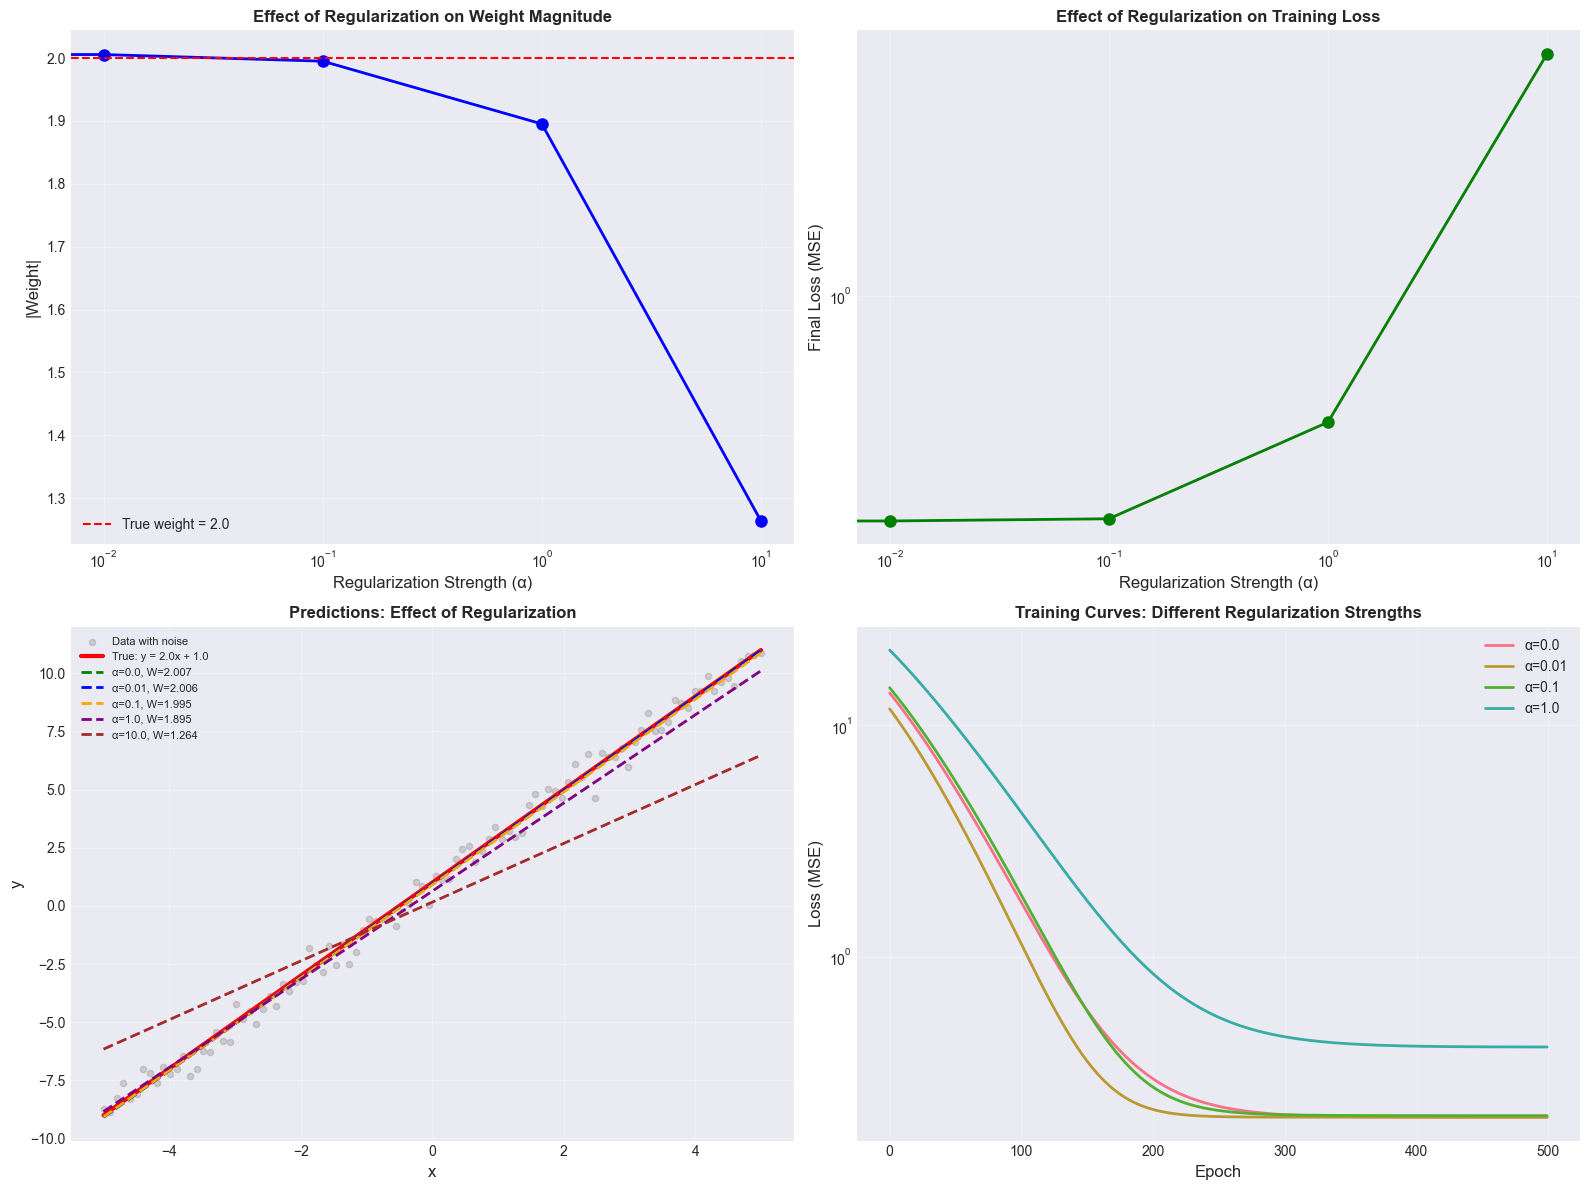


Key Observations:
1. As regularization (α) increases:
   - Weight magnitude decreases (shrinkage toward zero)
   - Model becomes simpler (less sensitive to data)
   - Training loss may increase slightly (bias-variance tradeoff)

2. Regularization helps when:
   - Data is noisy (like our example)
   - Risk of overfitting is high
   - We want more stable/robust predictions

3. Too much regularization (α too large):
   - Weights shrink too much toward zero
   - Model becomes too simple (underfitting)
   - May not capture the true relationship well


In [88]:
# Visualize effect of regularization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Weight magnitude vs regularization strength
alphas = list(ridge_results.keys())
weights = [ridge_results[alpha]['weight'] for alpha in alphas]
weight_mags = [abs(w) for w in weights]

axes[0, 0].plot(alphas, weight_mags, 'bo-', linewidth=2, markersize=8)
axes[0, 0].axhline(y=abs(true_slope), color='r', linestyle='--', label=f'True weight = {true_slope}')
axes[0, 0].set_xlabel('Regularization Strength (α)', fontsize=12)
axes[0, 0].set_ylabel('|Weight|', fontsize=12)
axes[0, 0].set_title('Effect of Regularization on Weight Magnitude', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# Plot 2: Training loss vs regularization strength
final_losses = [ridge_results[alpha]['final_loss'] for alpha in alphas]
axes[0, 1].plot(alphas, final_losses, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Regularization Strength (α)', fontsize=12)
axes[0, 1].set_ylabel('Final Loss (MSE)', fontsize=12)
axes[0, 1].set_title('Effect of Regularization on Training Loss', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')
axes[0, 1].set_yscale('log')

# Plot 3: Predictions for different regularization strengths
axes[1, 0].scatter(x, y, alpha=0.3, label='Data with noise', s=20, color='gray', zorder=1)
axes[1, 0].plot(x, y_true, 'r-', linewidth=3, label=f'True: y = {true_slope}x + {true_intercept}', zorder=2)

colors_map = {0.0: 'green', 0.01: 'blue', 0.1: 'orange', 1.0: 'purple', 10.0: 'brown'}
for alpha in [0.0, 0.01, 0.1, 1.0, 10.0]:
    result = ridge_results[alpha]
    axes[1, 0].plot(x, result['predictions'], '--', linewidth=2, 
                    label=f'α={alpha}, W={result["weight"]:.3f}', 
                    color=colors_map[alpha], zorder=3)

axes[1, 0].set_xlabel('x', fontsize=12)
axes[1, 0].set_ylabel('y', fontsize=12)
axes[1, 0].set_title('Predictions: Effect of Regularization', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Training curves for different regularization strengths
for alpha in [0.0, 0.01, 0.1, 1.0]:
    axes[1, 1].plot(ridge_results[alpha]['losses'], label=f'α={alpha}', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Loss (MSE)', fontsize=12)
axes[1, 1].set_title('Training Curves: Different Regularization Strengths', fontsize=12, fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Key Observations:")
print("=" * 70)
print("1. As regularization (α) increases:")
print("   - Weight magnitude decreases (shrinkage toward zero)")
print("   - Model becomes simpler (less sensitive to data)")
print("   - Training loss may increase slightly (bias-variance tradeoff)")

print("\n2. Regularization helps when:")
print("   - Data is noisy (like our example)")
print("   - Risk of overfitting is high")
print("   - We want more stable/robust predictions")

print("\n3. Too much regularization (α too large):")
print("   - Weights shrink too much toward zero")
print("   - Model becomes too simple (underfitting)")
print("   - May not capture the true relationship well")
print("=" * 70)

Comparison: PyTorch Ridge vs sklearn Ridge

Regularization strength (α = 0.0):
  Weight: PyTorch = 2.006896, sklearn = 2.006897, Diff = 0.000001
  Bias:   PyTorch = 0.946533, sklearn = 0.948077, Diff = 0.001544
  Loss:   PyTorch = 0.203729, sklearn = 0.203726, Diff = 0.000003

Regularization strength (α = 0.01):
  Weight: PyTorch = 2.005716, sklearn = 2.006873, Diff = 0.001157
  Bias:   PyTorch = 0.943360, sklearn = 0.948077, Diff = 0.004717
  Loss:   PyTorch = 0.203760, sklearn = 0.203726, Diff = 0.000034

Regularization strength (α = 0.1):
  Weight: PyTorch = 1.995160, sklearn = 2.006661, Diff = 0.011501
  Bias:   PyTorch = 0.902930, sklearn = 0.948077, Diff = 0.045147
  Loss:   PyTorch = 0.206936, sklearn = 0.203727, Diff = 0.003209

Regularization strength (α = 1.0):
  Weight: PyTorch = 1.895344, sklearn = 2.004539, Diff = 0.109195
  Bias:   PyTorch = 0.632051, sklearn = 0.948077, Diff = 0.316026
  Loss:   PyTorch = 0.409398, sklearn = 0.203773, Diff = 0.205625


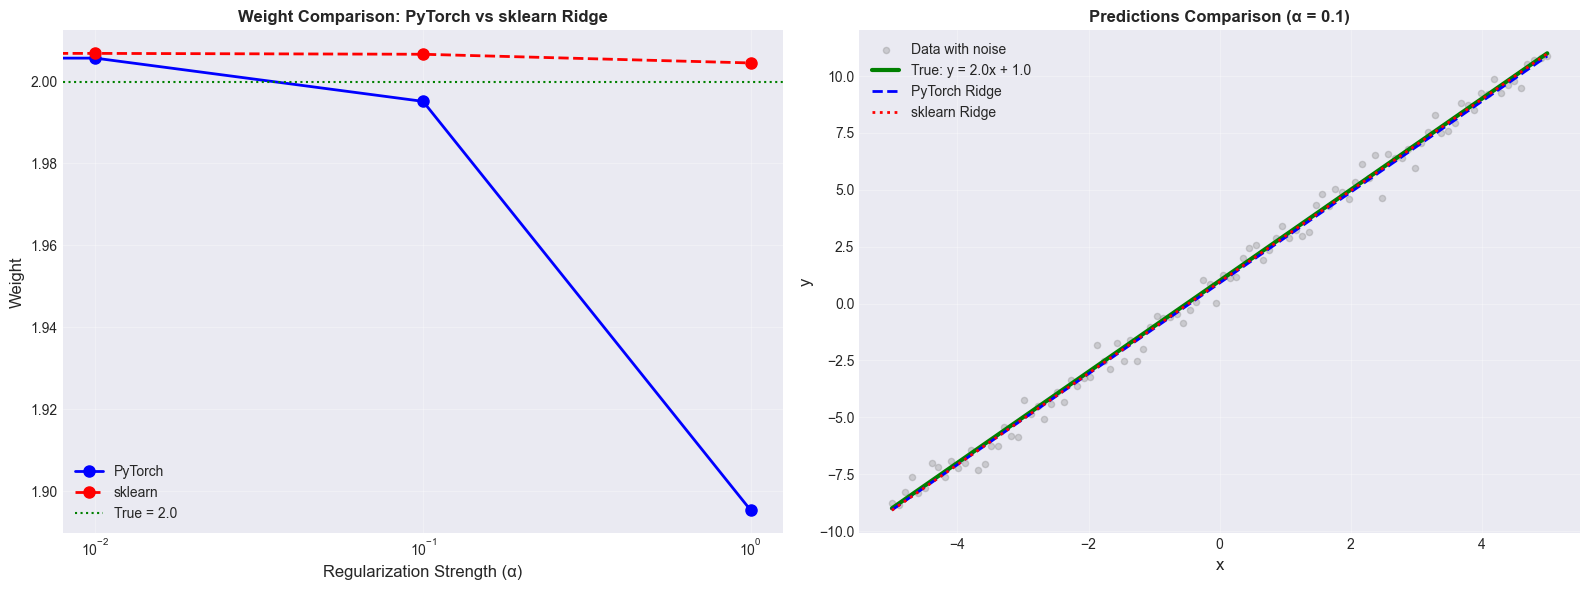


Key Insight: PyTorch Ridge (with weight_decay) and sklearn Ridge
learn the same function! Small differences are due to:
  - Different optimization algorithms (iterative vs analytical)
  - Numerical precision
  - Convergence tolerance


In [89]:
# Compare PyTorch Ridge with sklearn Ridge
print("=" * 70)
print("Comparison: PyTorch Ridge vs sklearn Ridge")
print("=" * 70)

comparison_results = []

for alpha in [0.0, 0.01, 0.1, 1.0]:
    # PyTorch result
    pytorch_weight = ridge_results[alpha]['weight']
    pytorch_bias = ridge_results[alpha]['bias']
    pytorch_loss = ridge_results[alpha]['final_loss']
    
    # sklearn Ridge
    ridge_sklearn = Ridge(alpha=alpha, fit_intercept=True)
    ridge_sklearn.fit(x, y.ravel())
    sklearn_weight = ridge_sklearn.coef_[0]
    sklearn_bias = ridge_sklearn.intercept_
    sklearn_pred = ridge_sklearn.predict(x)
    sklearn_loss = mean_squared_error(y, sklearn_pred)
    
    comparison_results.append({
        'alpha': alpha,
        'pytorch_weight': pytorch_weight,
        'sklearn_weight': sklearn_weight,
        'pytorch_bias': pytorch_bias,
        'sklearn_bias': sklearn_bias,
        'pytorch_loss': pytorch_loss,
        'sklearn_loss': sklearn_loss
    })
    
    print(f"\nRegularization strength (α = {alpha}):")
    print(f"  Weight: PyTorch = {pytorch_weight:.6f}, sklearn = {sklearn_weight:.6f}, Diff = {abs(pytorch_weight - sklearn_weight):.6f}")
    print(f"  Bias:   PyTorch = {pytorch_bias:.6f}, sklearn = {sklearn_bias:.6f}, Diff = {abs(pytorch_bias - sklearn_bias):.6f}")
    print(f"  Loss:   PyTorch = {pytorch_loss:.6f}, sklearn = {sklearn_loss:.6f}, Diff = {abs(pytorch_loss - sklearn_loss):.6f}")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Weight comparison
alphas_comp = [r['alpha'] for r in comparison_results]
pytorch_weights = [r['pytorch_weight'] for r in comparison_results]
sklearn_weights = [r['sklearn_weight'] for r in comparison_results]

axes[0].plot(alphas_comp, pytorch_weights, 'bo-', linewidth=2, markersize=8, label='PyTorch')
axes[0].plot(alphas_comp, sklearn_weights, 'ro--', linewidth=2, markersize=8, label='sklearn')
axes[0].axhline(y=true_slope, color='g', linestyle=':', label=f'True = {true_slope}')
axes[0].set_xlabel('Regularization Strength (α)', fontsize=12)
axes[0].set_ylabel('Weight', fontsize=12)
axes[0].set_title('Weight Comparison: PyTorch vs sklearn Ridge', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Plot 2: Predictions comparison for one alpha value
alpha_compare = 0.1
pytorch_pred = ridge_results[alpha_compare]['predictions']
sklearn_ridge = Ridge(alpha=alpha_compare, fit_intercept=True)
sklearn_ridge.fit(x, y.ravel())
sklearn_pred = sklearn_ridge.predict(x)

axes[1].scatter(x, y, alpha=0.3, label='Data with noise', s=20, color='gray', zorder=1)
axes[1].plot(x, y_true, 'g-', linewidth=3, label=f'True: y = {true_slope}x + {true_intercept}', zorder=2)
axes[1].plot(x, pytorch_pred, 'b--', linewidth=2, label='PyTorch Ridge', zorder=3)
axes[1].plot(x, sklearn_pred, 'r:', linewidth=2, label='sklearn Ridge', zorder=3)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('y', fontsize=12)
axes[1].set_title(f'Predictions Comparison (α = {alpha_compare})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("Key Insight: PyTorch Ridge (with weight_decay) and sklearn Ridge")
print("learn the same function! Small differences are due to:")
print("  - Different optimization algorithms (iterative vs analytical)")
print("  - Numerical precision")
print("  - Convergence tolerance")
print("=" * 70)

### 5b. Learning Regularization Strength as a Parameter

**Advanced Concept:** Instead of setting α as a hyperparameter, we can make it a **learnable parameter** of the neural network! The model will automatically learn the optimal regularization strength during training.

This demonstrates the flexibility of PyTorch - we can optimize not just weights, but also regularization parameters!

In [90]:
# Simple approach: Add alpha as a learnable parameter
# We use log_alpha to ensure alpha stays positive (alpha = exp(log_alpha))

initial_alphas = [0.001, 0.01, 0.1, 1.0]
learnable_alpha_results = {}

print("=" * 70)
print("Training Models with Learnable Regularization Strength (α)")
print("=" * 70)

for alpha_init in initial_alphas:
    # Create simple linear model
    model = nn.Linear(1, 1)
    
    # Add alpha as a learnable parameter (using log to keep it positive)
    log_alpha = nn.Parameter(torch.tensor(np.log(alpha_init), dtype=torch.float32))
    
    # Optimizer will optimize both model parameters AND log_alpha!
    optimizer = optim.Adam(list(model.parameters()) + [log_alpha], lr=0.01)
    
    criterion = nn.MSELoss()
    losses = []
    mse_losses = []
    alphas = []
    l2_penalties = []
    n_epochs = 1000
    
    print(f"\nTraining with initial α = {alpha_init}:")
    
    for epoch in range(n_epochs):
        # Forward pass
        y_pred = model(X_tensor)
        mse_loss = criterion(y_pred, y_tensor)
        
        # Compute L2 penalty (sum of squared weights)
        l2_penalty = sum(p.pow(2.0).sum() for p in model.parameters())
        
        # Get alpha (always positive)
        alpha = torch.exp(log_alpha)
        
        # Total loss = MSE + alpha * L2_penalty
        total_loss = mse_loss + alpha * l2_penalty
        
        # Backward pass
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        losses.append(total_loss.item())
        mse_losses.append(mse_loss.item())
        alphas.append(alpha.item())
        l2_penalties.append(l2_penalty.item())
        
        if (epoch + 1) % 200 == 0:
            weight = model.weight.data.item()
            bias = model.bias.data.item()
            print(f"  Epoch {epoch+1}: α = {alpha.item():.6f}, Weight = {weight:.6f}, Bias = {bias:.6f}, "
                  f"MSE = {mse_loss.item():.6f}, L2 = {l2_penalty.item():.6f}")
    
    # Get final predictions and parameters
    with torch.no_grad():
        y_pred_tensor = model(X_tensor)
        y_pred_np = y_pred_tensor.numpy()
        final_weight = model.weight.data.item()
        final_bias = model.bias.data.item()
        final_alpha = torch.exp(log_alpha).item()
    
    learnable_alpha_results[alpha_init] = {
        'weight': final_weight,
        'bias': final_bias,
        'alpha': final_alpha,
        'alpha_history': alphas,
        'predictions': y_pred_np,
        'total_losses': losses,
        'mse_losses': mse_losses,
        'l2_penalties': l2_penalties,
        'final_mse': mse_losses[-1]
    }
    
    print(f"\n  Final: α = {final_alpha:.6f} (started at {alpha_init:.6f})")
    print(f"         Weight = {final_weight:.6f}, Bias = {final_bias:.6f}")
    print(f"         Final MSE = {mse_losses[-1]:.6f}")

print("\n" + "=" * 70)
print("Observation: The model learns different α values depending on the initial value!")
print("This shows that α optimization can have multiple local minima.")
print("=" * 70)

Training Models with Learnable Regularization Strength (α)

Training with initial α = 0.001:
  Epoch 200: α = 0.000122, Weight = 1.143184, Bias = 0.948141, MSE = 6.629037, L2 = 2.193001
  Epoch 400: α = 0.000030, Weight = 1.831835, Bias = 0.948046, MSE = 0.469270, L2 = 4.248292
  Epoch 600: α = 0.000013, Weight = 1.987828, Bias = 0.948064, MSE = 0.206897, L2 = 4.849320
  Epoch 800: α = 0.000008, Weight = 2.005814, Bias = 0.948069, MSE = 0.203736, L2 = 4.922055
  Epoch 1000: α = 0.000005, Weight = 2.006866, Bias = 0.948072, MSE = 0.203726, L2 = 4.926346

  Final: α = 0.000005 (started at 0.001000)
         Weight = 2.006866, Bias = 0.948072
         Final MSE = 0.203726

Training with initial α = 0.01:
  Epoch 200: α = 0.001013, Weight = 1.148081, Bias = 0.920240, MSE = 6.557496, L2 = 2.150596
  Epoch 400: α = 0.000219, Weight = 1.833888, Bias = 0.947824, MSE = 0.463099, L2 = 4.255434
  Epoch 600: α = 0.000095, Weight = 1.988210, Bias = 0.947980, MSE = 0.206771, L2 = 4.850695
  Epoch 80

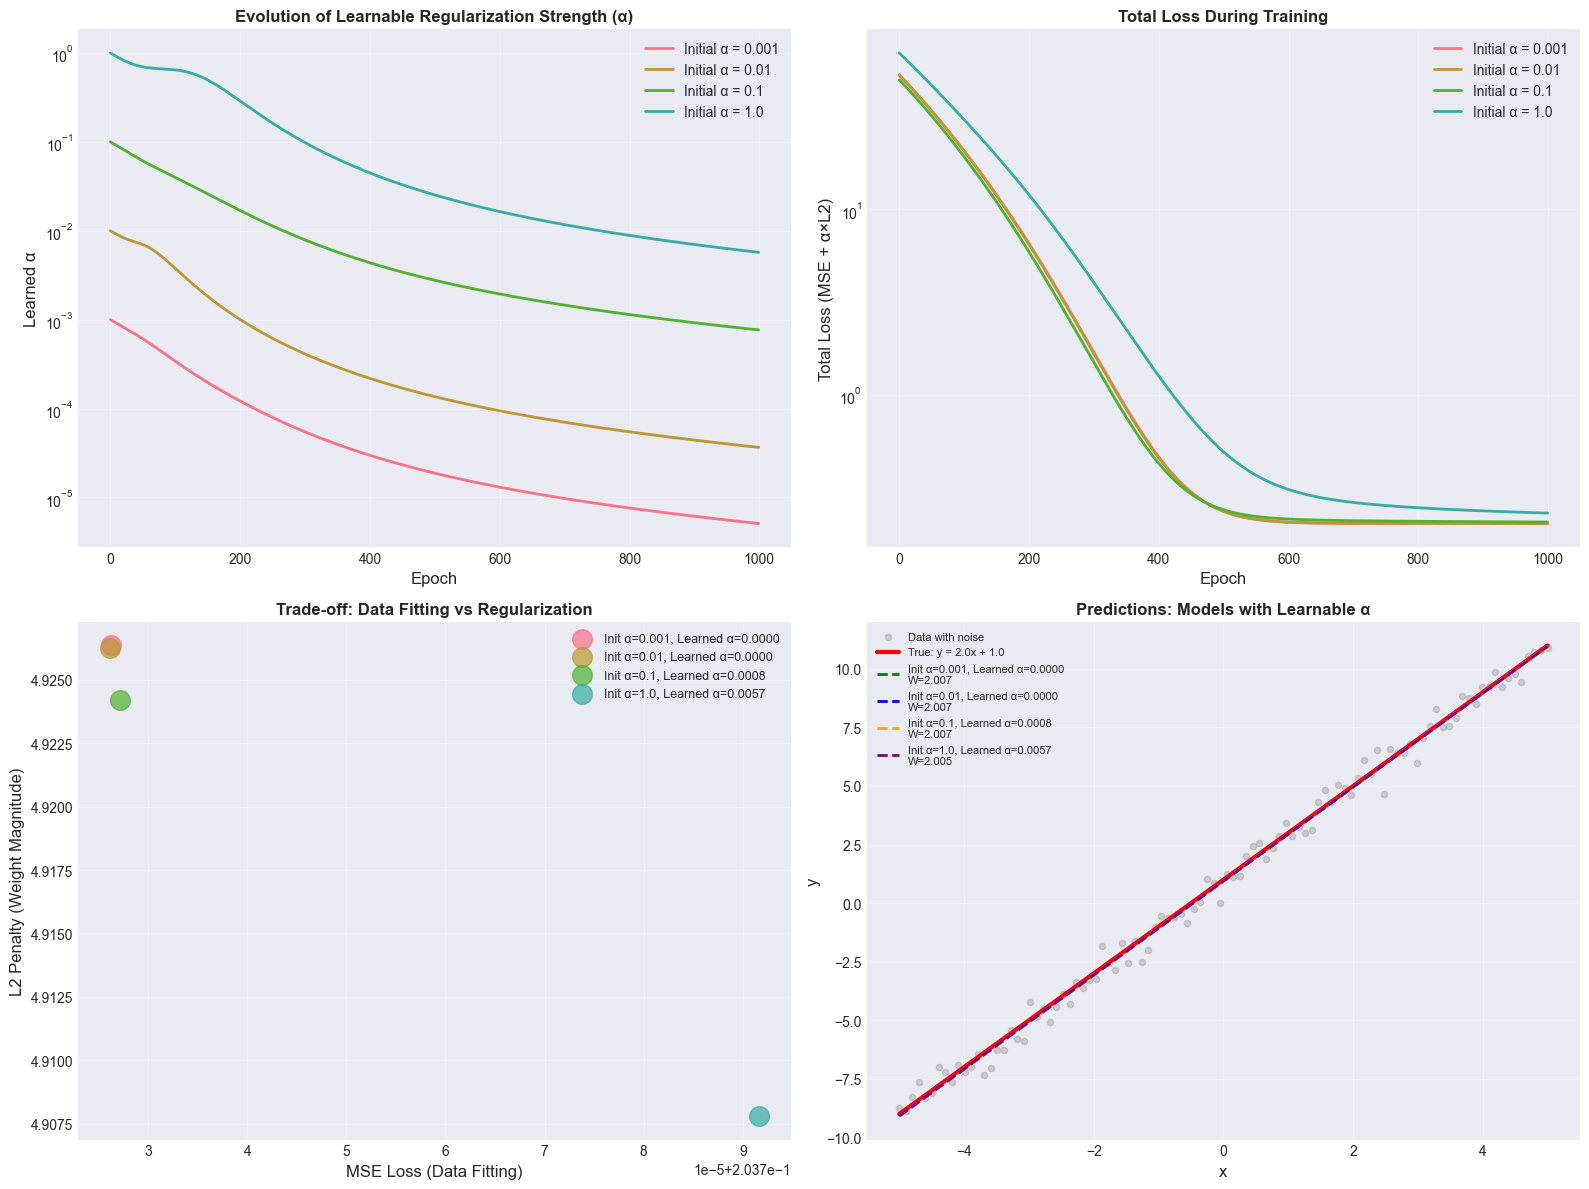


Summary: Learnable α vs Fixed α
Initial α    Learned α    Weight       Bias         Final MSE   
--------------------------------------------------------------------------------
0.001        0.000005     2.006866     0.948072     0.203726    
0.010        0.000037     2.006859     0.948041     0.203726    
0.100        0.000765     2.006675     0.947350     0.203727    
1.000        0.005707     2.004938     0.942388     0.203792    

--------------------------------------------------------------------------------
For comparison - Fixed α results:
--------------------------------------------------------------------------------
Fixed α      Weight       Bias         Final MSE   
0.000        2.006896     0.946533     0.203729    
0.010        2.005716     0.943360     0.203760    
0.100        1.995160     0.902930     0.206936    
1.000        1.895344     0.632051     0.409398    

Key Insights:
1. The model can learn α automatically during training!
2. Different initial α values lea

In [91]:
# Visualize how learnable alpha evolves during training
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Alpha evolution during training
for alpha_init, result in learnable_alpha_results.items():
    axes[0, 0].plot(result['alpha_history'], label=f'Initial α = {alpha_init}', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Learned α', fontsize=12)
axes[0, 0].set_title('Evolution of Learnable Regularization Strength (α)', fontsize=12, fontweight='bold')
axes[0, 0].set_yscale('log')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Total loss (MSE + α*L2) during training
for alpha_init, result in learnable_alpha_results.items():
    axes[0, 1].plot(result['total_losses'], label=f'Initial α = {alpha_init}', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Total Loss (MSE + α×L2)', fontsize=12)
axes[0, 1].set_title('Total Loss During Training', fontsize=12, fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: MSE loss (data fitting) vs L2 penalty (regularization)
for alpha_init, result in learnable_alpha_results.items():
    final_alpha = result['alpha']
    final_mse = result['final_mse']
    final_l2 = result['l2_penalties'][-1]
    axes[1, 0].scatter(final_mse, final_l2, s=200, alpha=0.7, 
                      label=f'Init α={alpha_init}, Learned α={final_alpha:.4f}')
axes[1, 0].set_xlabel('MSE Loss (Data Fitting)', fontsize=12)
axes[1, 0].set_ylabel('L2 Penalty (Weight Magnitude)', fontsize=12)
axes[1, 0].set_title('Trade-off: Data Fitting vs Regularization', fontsize=12, fontweight='bold')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Predictions comparison
axes[1, 1].scatter(x, y, alpha=0.3, label='Data with noise', s=20, color='gray', zorder=1)
axes[1, 1].plot(x, y_true, 'r-', linewidth=3, label=f'True: y = {true_slope}x + {true_intercept}', zorder=2)

colors_map = {0.001: 'green', 0.01: 'blue', 0.1: 'orange', 1.0: 'purple'}
for alpha_init, result in learnable_alpha_results.items():
    learned_alpha = result['alpha']
    axes[1, 1].plot(x, result['predictions'], '--', linewidth=2, 
                    label=f'Init α={alpha_init}, Learned α={learned_alpha:.4f}\nW={result["weight"]:.3f}', 
                    color=colors_map[alpha_init], zorder=3)

axes[1, 1].set_xlabel('x', fontsize=12)
axes[1, 1].set_ylabel('y', fontsize=12)
axes[1, 1].set_title('Predictions: Models with Learnable α', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 80)
print("Summary: Learnable α vs Fixed α")
print("=" * 80)
print(f"{'Initial α':<12} {'Learned α':<12} {'Weight':<12} {'Bias':<12} {'Final MSE':<12}")
print("-" * 80)
for alpha_init, result in learnable_alpha_results.items():
    print(f"{alpha_init:<12.3f} {result['alpha']:<12.6f} {result['weight']:<12.6f} "
          f"{result['bias']:<12.6f} {result['final_mse']:<12.6f}")

# Compare with fixed alpha results
print("\n" + "-" * 80)
print("For comparison - Fixed α results:")
print("-" * 80)
print(f"{'Fixed α':<12} {'Weight':<12} {'Bias':<12} {'Final MSE':<12}")
for alpha in [0.0, 0.01, 0.1, 1.0]:
    if alpha in ridge_results:
        result = ridge_results[alpha]
        print(f"{alpha:<12.3f} {result['weight']:<12.6f} {result['bias']:<12.6f} {result['final_loss']:<12.6f}")

print("\n" + "=" * 80)
print("Key Insights:")
print("=" * 80)
print("1. The model can learn α automatically during training!")
print("2. Different initial α values lead to different learned α values")
print("3. The learned α balances data fitting (MSE) and regularization (L2)")
print("4. This demonstrates PyTorch's flexibility - we can optimize ANY parameter")
print("5. In practice, this is less common because:")
print("   - α is usually tuned via cross-validation (more reliable)")
print("   - Learning α can lead to overfitting to training data")
print("   - But it's a powerful demonstration of what's possible!")
print("=" * 80)

**Part 3 Summary:**
- ✅ Implemented Ridge regression as a neural network using weight decay in PyTorch
- ✅ Demonstrated how regularization shrinks weights toward zero
- ✅ Compared with sklearn Ridge - they learn the same function!
- ✅ Visualized the effect of different regularization strengths

**Key Takeaways:**
- **Weight decay** in PyTorch optimizers = **L2 regularization** = **Ridge regression**
- Regularization helps prevent overfitting by penalizing large weights
- As α increases: weights shrink, model becomes simpler, but may underfit if too large
- PyTorch uses iterative optimization (Adam with weight_decay)
- sklearn uses analytical solution (closed-form)
- Both methods learn: `y = Wx + b` with L2 penalty on weights

**Regularization Trade-off:**
- **Too little regularization (α ≈ 0):** Model may overfit to noise
- **Right amount (α moderate):** Model generalizes well, robust to noise
- **Too much regularization (α large):** Model underfits, weights too small

**Next:** In Part 4, we'll apply these models to real financial data!

## Part 4: Application to Financial Data

### 6. Data Preparation for Neural Networks

**Why Data Preparation Matters:**
- **Scaling/Normalization:** Neural networks are sensitive to input scale. Features with different scales can cause:
  - Slow or unstable training
  - Activation functions to saturate (e.g., sigmoid saturates for large inputs)
  - Some features dominating others
- **Standardization:** Transform features to have mean=0 and std=1
- **Missing values:** Handle missing data appropriately
- **Outliers:** Consider winsorizing or clipping extreme values

**We'll demonstrate:**
1. Load financial features and returns
2. Show the importance of scaling through activation function behavior
3. Train linear and Ridge models on financial data
4. Evaluate performance

In [92]:
# Load data using functions from L-3GV
def load_ff_crsp():
    """Load Fama-French factors and CRSP stock returns"""
    crsp = pd.read_parquet(FileNames.fn_crsp)
    ff = pd.read_parquet(FileNames.fn_ff_factors)
    return crsp, ff

def load_features(crsp=True, om=True, merge=True, 
                  cols_to_drop=['overlap_start', 'overlap_end', 'secid']):
    """Load features from CRSP and OptionMetrics"""
    features_crsp, features_om = pd.DataFrame(), pd.DataFrame()
    if crsp:
        features_crsp = pd.read_parquet(FileNames.fn_stock_features_labels)
        features_crsp = features_crsp.sort_index()
    if om:
        features_om = pd.read_parquet(FileNames.fn_option_features)
        features_om = features_om.sort_index()
    if merge:
        res = pd.concat([features_crsp, features_om], axis=1).sort_index()
        cols_to_drop = [z for z in cols_to_drop if z in res.columns]
        res = res.drop(columns=cols_to_drop)
    else:
        res = (features_crsp, features_om)
    return res

# Load the data
print("Loading financial data...")
crsp, ff = load_ff_crsp()
features = load_features(merge=True)

print(f"\nData shapes:")
print(f"  CRSP: {crsp.shape}")
print(f"  FF factors: {ff.shape}")
print(f"  Features: {features.shape}")

# Check for returns column
if 'ret' in features.columns:
    print(f"\nFeatures include returns column 'ret'")
    print(f"  Number of observations with returns: {features['ret'].notna().sum()}")
    print(f"  Number of missing returns: {features['ret'].isna().sum()}")
else:
    print("\nWarning: 'ret' column not found in features")

# Display feature statistics
print(f"\nFeature columns ({len(features.columns)}):")
print(features.columns.tolist()[:10], "..." if len(features.columns) > 10 else "")

# Show basic statistics (exclude fret1d/fret5d as they are labels, not features)
exclude_cols = ['ret', 'fret1d', 'fret5d']
feature_cols_for_stats = [col for col in features.columns if col not in exclude_cols]
print(f"\nBasic statistics (first 5 features, excluding labels):")
if len(feature_cols_for_stats) >= 5:
    print(features[feature_cols_for_stats[:5]].describe().round(3))
else:
    print(features[feature_cols_for_stats].describe().round(3))

Loading financial data...

Data shapes:
  CRSP: (1768460, 12)
  FF factors: (7550, 7)
  Features: (1776703, 15)

Features include returns column 'ret'
  Number of observations with returns: 1590520
  Number of missing returns: 186183

Feature columns (15):
['ret', 'mktcap', 'mom12m', 'mom6m', 'rev1m', 'beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom', 'idvar_ff4'] ...

Basic statistics (first 5 features, excluding labels):
            mktcap       mom12m        mom6m        rev1m   beta_mktrf
count    1590522.0  1590776.000  1590758.000  1590536.000  1590776.000
mean     48373.176        0.150        0.071        0.012        0.997
std     135031.322        0.592        0.312        0.106        0.342
min         14.169       -0.983       -0.952       -0.908       -5.665
25%       9259.437       -0.077       -0.070       -0.039        0.784
50%      18369.953        0.107        0.057        0.011        0.990
75%        41522.0        0.303        0.185        0.060        1.201
max   

### 6b. Why Scaling Matters: Effect on Activation Functions

**Problem:** If inputs to activation functions are too large or too small, they can saturate, making gradients vanish and training slow or impossible.

Let's demonstrate this with a simple example showing how unscaled vs scaled data affects activation function outputs.

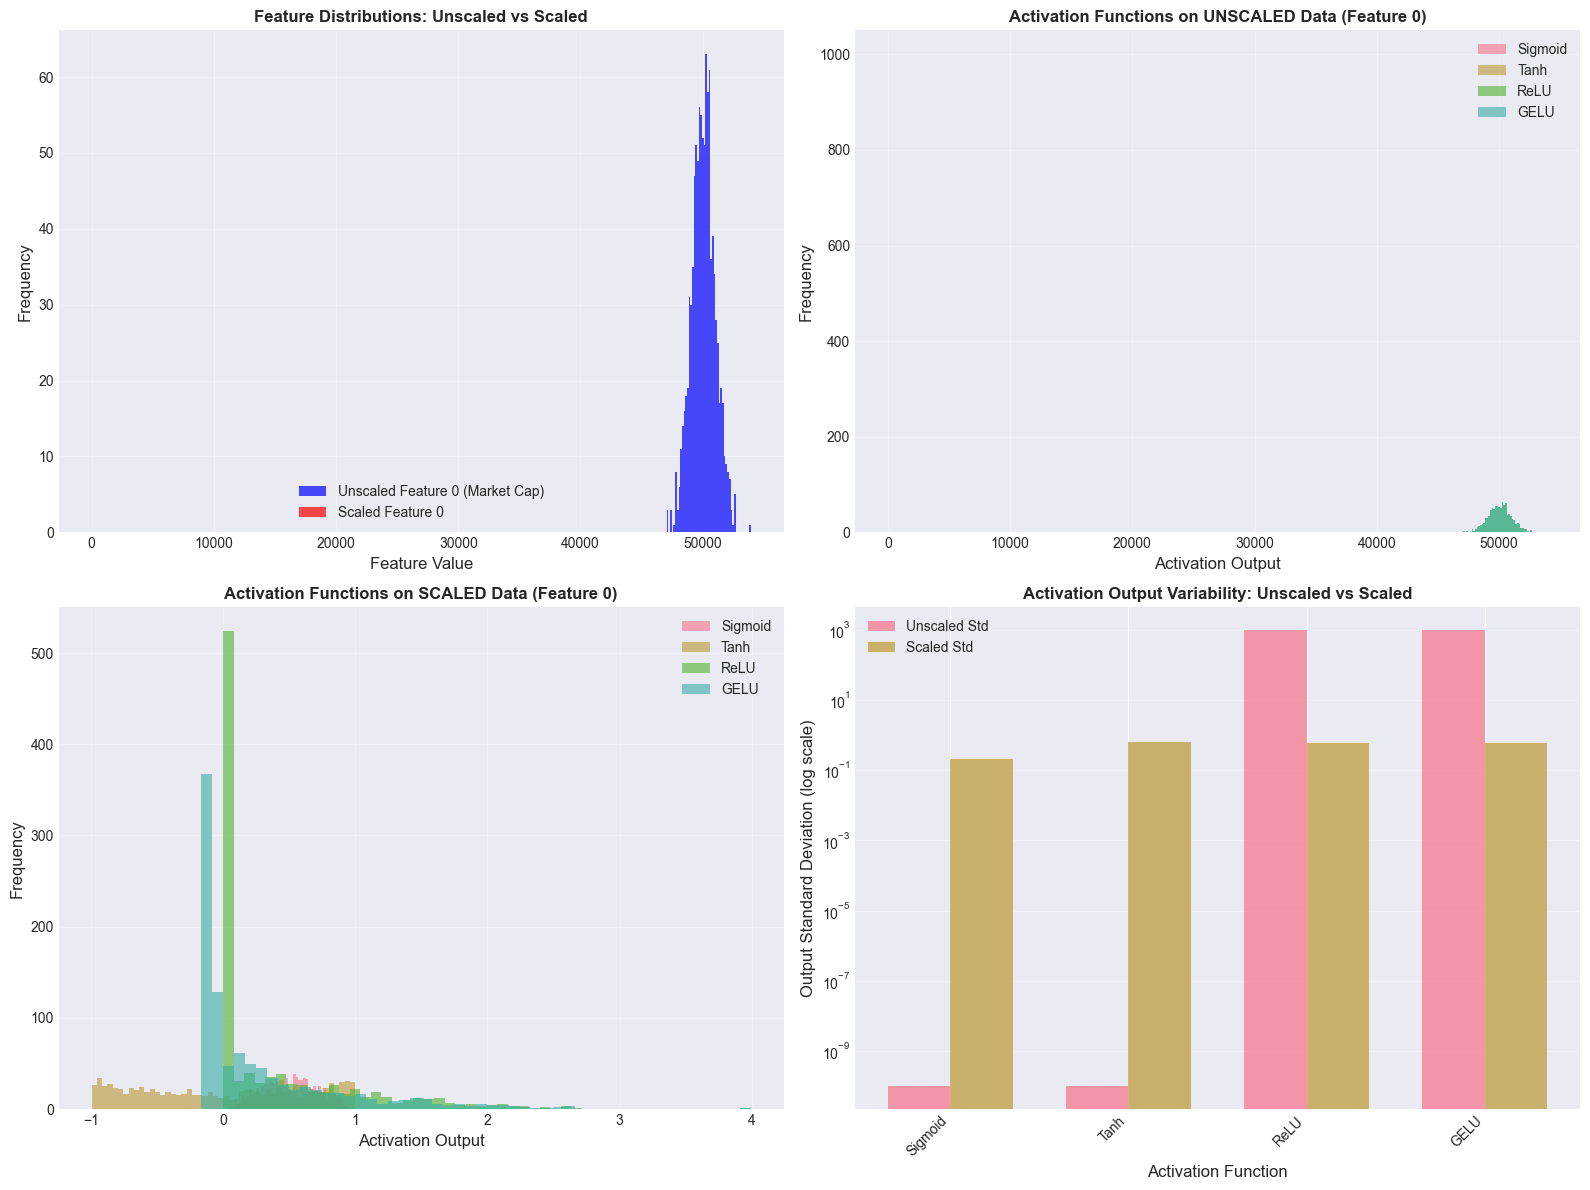

Activation Function Output Statistics
Activation  Unscaled Mean  Unscaled Std  Scaled Mean  Scaled Std
   Sigmoid       0.999955  3.330669e-16     0.499826    0.207509
      Tanh       1.000000  0.000000e+00    -0.001149    0.624348
      ReLU   50055.011029  9.697271e+02     0.397640    0.586574
      GELU   50055.011029  9.697271e+02     0.280214    0.592436

Key Observations:
1. UNSCALED data:
   - Sigmoid/Tanh saturate (outputs near 0 or 1) for large inputs
   - ReLU outputs are dominated by large-scale features
   - Different features have vastly different activation ranges
   - Gradients can vanish (sigmoid/tanh) or explode (ReLU)

2. SCALED data:
   - All features have similar activation ranges
   - Activation functions operate in their 'active' regions
   - Gradients flow better, training is more stable
   - Model can learn from all features equally

3. Conclusion:
   - ALWAYS scale/normalize features before feeding to neural networks!
   - StandardScaler (mean=0, std=1) is the

In [93]:
# Demonstrate the effect of scaling on activation functions
# Simulate unscaled financial features (e.g., market cap in millions, returns in decimals)
np.random.seed(42)

# Create synthetic unscaled features (simulating real financial data)
n_samples = 1000
unscaled_features = np.random.randn(n_samples, 3)
# Simulate different scales: feature 0 (large scale, e.g., market cap), 
# feature 1 (medium scale), feature 2 (small scale, e.g., returns)
unscaled_features[:, 0] = unscaled_features[:, 0] * 1000 + 50000  # Market cap: ~50,000 ± 1000
unscaled_features[:, 1] = unscaled_features[:, 1] * 10 + 100        # Medium scale
unscaled_features[:, 2] = unscaled_features[:, 2] * 0.01 + 0.02    # Returns: ~0.02 ± 0.01

# Standardize features (mean=0, std=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(unscaled_features)

# Apply activation functions to both scaled and unscaled data
activations = {
    'Sigmoid': lambda x: 1 / (1 + np.exp(-np.clip(x, -10, 10))),  # Clip to avoid overflow
    'Tanh': np.tanh,
    'ReLU': lambda x: np.maximum(0, x),
    'GELU': lambda x: x * 0.5 * (1 + np.tanh(np.sqrt(2/np.pi) * (x + 0.044715 * x**3)))
}

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Feature distributions (unscaled vs scaled)
axes[0, 0].hist(unscaled_features[:, 0], bins=50, alpha=0.7, label='Unscaled Feature 0 (Market Cap)', color='blue')
axes[0, 0].hist(scaled_features[:, 0], bins=50, alpha=0.7, label='Scaled Feature 0', color='red')
axes[0, 0].set_xlabel('Feature Value', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].set_title('Feature Distributions: Unscaled vs Scaled', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Activation function outputs on unscaled data
for name, func in activations.items():
    output = func(unscaled_features[:, 0])
    axes[0, 1].hist(output, bins=50, alpha=0.6, label=name)
axes[0, 1].set_xlabel('Activation Output', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].set_title('Activation Functions on UNSCALED Data (Feature 0)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Activation function outputs on scaled data
for name, func in activations.items():
    output = func(scaled_features[:, 0])
    axes[1, 0].hist(output, bins=50, alpha=0.6, label=name)
axes[1, 0].set_xlabel('Activation Output', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_title('Activation Functions on SCALED Data (Feature 0)', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Compare activation outputs (mean and std)
activation_stats = []
for name, func in activations.items():
    unscaled_output = func(unscaled_features[:, 0])
    scaled_output = func(scaled_features[:, 0])
    activation_stats.append({
        'Activation': name,
        'Unscaled Mean': np.mean(unscaled_output),
        'Unscaled Std': np.std(unscaled_output),
        'Scaled Mean': np.mean(scaled_output),
        'Scaled Std': np.std(scaled_output)
    })

stats_df = pd.DataFrame(activation_stats)
x_pos = np.arange(len(stats_df))
width = 0.35

# Use log scale to show all bars (unscaled values have very different scales)
axes[1, 1].bar(x_pos - width/2, np.maximum(stats_df['Unscaled Std'], 1e-10), width, label='Unscaled Std', alpha=0.7)
axes[1, 1].bar(x_pos + width/2, np.maximum(stats_df['Scaled Std'], 1e-10), width, label='Scaled Std', alpha=0.7)
axes[1, 1].set_xlabel('Activation Function', fontsize=12)
axes[1, 1].set_ylabel('Output Standard Deviation (log scale)', fontsize=12)
axes[1, 1].set_title('Activation Output Variability: Unscaled vs Scaled', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(stats_df['Activation'], rotation=45, ha='right')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print statistics
print("=" * 80)
print("Activation Function Output Statistics")
print("=" * 80)
print(stats_df.to_string(index=False))
print("\n" + "=" * 80)
print("Key Observations:")
print("=" * 80)
print("1. UNSCALED data:")
print("   - Sigmoid/Tanh saturate (outputs near 0 or 1) for large inputs")
print("   - ReLU outputs are dominated by large-scale features")
print("   - Different features have vastly different activation ranges")
print("   - Gradients can vanish (sigmoid/tanh) or explode (ReLU)")

print("\n2. SCALED data:")
print("   - All features have similar activation ranges")
print("   - Activation functions operate in their 'active' regions")
print("   - Gradients flow better, training is more stable")
print("   - Model can learn from all features equally")

print("\n3. Conclusion:")
print("   - ALWAYS scale/normalize features before feeding to neural networks!")
print("   - StandardScaler (mean=0, std=1) is the most common choice")
print("   - Fit scaler on training data, transform test data with same scaler")
print("=" * 80)

### 7. Prepare Financial Data for Modeling

Now let's prepare the actual financial data:
1. Extract features and labels (`fret1d` or `fret5d` - these are **labels**, not features!)
2. Handle missing values
3. Create train/test split (time-series split - **no random shuffling!**)
4. Scale features (choose method via `SCALING_METHOD` switch)

**Scaling Method Switch:**
- **Default:** `SCALING_METHOD = 'cross_sectional'` - Normalize within each date (across stocks)
  - Better for IC-based strategies, focuses on relative rankings
  - Removes time-varying levels and regime changes
- **Alternative:** `SCALING_METHOD = 'panel'` - Normalize across all dates and stocks (StandardScaler)
  - Preserves absolute levels, consistent feature scales

**Important:** 
- `fret1d` and `fret5d` are forward returns (labels), not features. They represent the return we want to predict.
- Change the `SCALING_METHOD` variable in the code cell below to switch between methods.

In [94]:
# Prepare financial data for modeling
# Use fret1d or fret5d as labels (forward returns - these are labels, not features!)
# Exclude fret1d, fret5d, and 'ret' from features

# ============================================================================
# SCALING METHOD SWITCH
# ============================================================================
# Choose scaling method: 'cross_sectional' or 'panel'
# - 'cross_sectional': Normalize within each date (across stocks) - DEFAULT, better for IC-based strategies
# - 'panel': Normalize across all dates and stocks (StandardScaler) - preserves absolute levels
SCALING_METHOD = 'cross_sectional'  # Change to 'panel' to use panel scaling instead

print(f"Scaling method: {SCALING_METHOD}")
print("  (Change SCALING_METHOD variable above to switch between 'cross_sectional' and 'panel')")

# Time-split helper (prevents data leakage)
def time_train_test_split(dates, train_frac=0.8, val_days=20):
    """Split dates chronologically for time-series data"""
    split = int(len(dates) * train_frac)
    train_dates = dates[:split]
    val_dates = dates[split-val_days:split]  # small holdout from end of train for val
    test_dates = dates[split:]
    return train_dates, val_dates, test_dates

# Check which forward return columns are available
label_cols = ['fret1d', 'fret5d']
available_labels = [col for col in label_cols if col in features.columns]

if not available_labels:
    print("Error: Neither 'fret1d' nor 'fret5d' found. Please check the data.")
    print(f"Available columns: {features.columns.tolist()[:10]}...")
else:
    # Use fret1d as default (1-day forward return), or fret5d if fret1d not available
    label_col = available_labels[0]
    print(f"Using '{label_col}' as target label (forward return)")
    
    # Separate features and target
    # Exclude label columns and 'ret' from features
    exclude_cols = ['ret', 'fret1d', 'fret5d']
    feature_cols = [col for col in features.columns if col not in exclude_cols]
    X = features[feature_cols].copy()
    y = features[label_col].copy()
    
    print(f"  Features: {len(feature_cols)} columns")
    print(f"  Label: {label_col}")
    print(f"  y non-null fraction: {y.notna().mean():.4f}")
    
    # Drop rows with missing returns (we can't predict what we don't have)
    valid_mask = y.notna()
    X = X[valid_mask]
    y = y[valid_mask]
    
    print(f"Data after removing missing returns:")
    print(f"  Features shape: {X.shape}")
    print(f"  Returns shape: {y.shape}")
    print(f"  Missing values in features: {X.isna().sum().sum()}")
    
    # Handle missing values in features (simple forward fill, then drop remaining)
    # In practice, you might want more sophisticated imputation
    X = X.ffill().fillna(0)  # Forward fill, then fill remaining with 0
    
    # Time-series split: use earlier data for training, later for testing
    # IMPORTANT: No random shuffling for financial data!
    # Note: MultiIndex structure: level 0 = stock IDs, level 1 = dates
    if isinstance(X.index, pd.MultiIndex):
        dates = X.index.get_level_values(1).unique()  # level 1 = dates
        dates_sorted = sorted(dates)
        train_dates, val_dates, test_dates = time_train_test_split(dates_sorted, train_frac=0.8, val_days=20)
        
        train_mask = X.index.get_level_values(1).isin(train_dates)  # level 1 = dates
        val_mask = X.index.get_level_values(1).isin(val_dates)  # level 1 = dates
        test_mask = X.index.get_level_values(1).isin(test_dates)  # level 1 = dates
    else:
        # If not MultiIndex, assume sequential split
        n_total = len(X)
        n_train = int(n_total * 0.8)
        n_val = 20  # small validation set
        
        train_mask = np.zeros(len(X), dtype=bool)
        val_mask = np.zeros(len(X), dtype=bool)
        test_mask = np.zeros(len(X), dtype=bool)
        
        train_mask[:n_train-n_val] = True
        val_mask[n_train-n_val:n_train] = True
        test_mask[n_train:] = True
    
    X_train = X[train_mask].copy()
    X_val = X[val_mask].copy()
    X_test = X[test_mask].copy()
    y_train = y[train_mask].copy()
    y_val = y[val_mask].copy()
    y_test = y[test_mask].copy()
    
    print(f"\nTime-based Train/Val/Test Split (no random shuffling!):")
    print(f"  Training: {len(X_train)} samples")
    print(f"  Validation: {len(X_val)} samples")
    print(f"  Testing: {len(X_test)} samples")
    print(f"  Split ratio: {len(X_train)/len(X):.2%} train, {len(X_val)/len(X):.2%} val, {len(X_test)/len(X):.2%} test")
    
    # ============================================================================
    # SCALING: Cross-Sectional Z-Scoring or Panel Scaling
    # ============================================================================
    
    def cross_sectional_zscore(X_df):
        """
        Cross-sectional z-scoring: normalize within each date (across stocks).
        For MultiIndex (stock_id, date), normalizes each date separately.
        Returns numpy array with float64 dtype.
        """
        if isinstance(X_df.index, pd.MultiIndex):
            # MultiIndex: level 0 = stock IDs, level 1 = dates
            dates = X_df.index.get_level_values(1).unique()
            
            # Initialize output array
            X_scaled = np.zeros_like(X_df.values, dtype=np.float64)
            X_df_values = X_df.values.astype(np.float64)
            
            # Get date indices for efficient lookup
            date_level = X_df.index.get_level_values(1)
            
            for date in dates:
                date_mask = date_level == date
                date_indices = np.where(date_mask)[0]
                
                if len(date_indices) > 0:
                    # Get data for this date
                    date_data = X_df_values[date_indices, :]
                    
                    # Compute mean and std for this date (across stocks)
                    date_mean = np.nanmean(date_data, axis=0, keepdims=True)
                    date_std = np.nanstd(date_data, axis=0, keepdims=True)
                    
                    # Avoid division by zero (set std=1 if all values are same)
                    date_std = np.where(date_std == 0, 1.0, date_std)
                    
                    # Normalize: z = (x - mean) / std
                    X_scaled[date_indices, :] = (date_data - date_mean) / date_std
        else:
            # Simple index: normalize across all samples
            X_df_values = X_df.values.astype(np.float64)
            X_mean = np.nanmean(X_df_values, axis=0, keepdims=True)
            X_std = np.nanstd(X_df_values, axis=0, keepdims=True)
            X_std = np.where(X_std == 0, 1.0, X_std)
            X_scaled = (X_df_values - X_mean) / X_std
        
        return X_scaled
    
    # Apply scaling based on SCALING_METHOD switch
    if SCALING_METHOD == 'cross_sectional':
        print("\nScaling features using cross-sectional z-scoring...")
        print("  (Normalizing within each date, across stocks - better for relative value strategies)")
        
        # Apply cross-sectional z-scoring to each split
        X_train_scaled = cross_sectional_zscore(X_train)
        X_val_scaled = cross_sectional_zscore(X_val)
        X_test_scaled = cross_sectional_zscore(X_test)
        
    elif SCALING_METHOD == 'panel':
        print("\nScaling features using panel scaling (StandardScaler)...")
        print("  (Normalizing across all dates and stocks - preserves absolute levels)")
        
        # Panel scaling: fit on training, transform all splits
        scaler_X = StandardScaler()
        X_train_scaled = scaler_X.fit_transform(X_train).astype(np.float64)
        X_val_scaled = scaler_X.transform(X_val).astype(np.float64)
        X_test_scaled = scaler_X.transform(X_test).astype(np.float64)
        
    else:
        raise ValueError(f"Unknown SCALING_METHOD: {SCALING_METHOD}. Use 'cross_sectional' or 'panel'")
    
    # Ensure float32 for PyTorch (more memory efficient)
    X_train_scaled = X_train_scaled.astype(np.float32)
    X_val_scaled = X_val_scaled.astype(np.float32)
    X_test_scaled = X_test_scaled.astype(np.float32)
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.FloatTensor(X_train_scaled)
    X_val_tensor = torch.FloatTensor(X_val_scaled)
    X_test_tensor = torch.FloatTensor(X_test_scaled)
    y_train_tensor = torch.FloatTensor(y_train.values.reshape(-1, 1))
    y_val_tensor = torch.FloatTensor(y_val.values.reshape(-1, 1))
    y_test_tensor = torch.FloatTensor(y_test.values.reshape(-1, 1))
    
    print(f"\nData preparation complete!")
    print(f"  Training features: {X_train_tensor.shape}")
    print(f"  Validation features: {X_val_tensor.shape}")
    print(f"  Test features: {X_test_tensor.shape}")
    print(f"  Number of features: {X_train_tensor.shape[1]}")

Scaling method: cross_sectional
  (Change SCALING_METHOD variable above to switch between 'cross_sectional' and 'panel')
Error: Neither 'fret1d' nor 'fret5d' found. Please check the data.
Available columns: ['ret', 'mktcap', 'mom12m', 'mom6m', 'rev1m', 'beta_mktrf', 'beta_smb', 'beta_hml', 'beta_mom', 'idvar_ff4']...


### 7a. Panel Scaling vs Cross-Sectional Z-Scoring: Which is Better?

**Current approach (Panel Scaling):**
- Uses `StandardScaler()` which normalizes each feature across **all dates and stocks** in training data
- Each feature gets a single mean and std computed from the entire training panel
- Formula: `z = (x - μ_panel) / σ_panel` where μ and σ are computed across all training data

**Alternative (Cross-Sectional Z-Scoring):**
- Normalizes each feature **within each date** (across stocks only)
- Each date gets its own mean=0, std=1 for each feature
- Formula: `z_t = (x_t - μ_t) / σ_t` where μ_t and σ_t are computed per date t

**Why Cross-Sectional Z-Scoring is Often Better for Financial ML:**

1. **Removes time-varying levels:** Market-wide trends and regime changes don't affect relative rankings
2. **Focuses on relative value:** Aligns with how portfolio managers think (which stocks are cheap/expensive relative to peers today?)
3. **Better for IC-based strategies:** IC measures cross-sectional correlation, so cross-sectional scaling is more natural
4. **Robust to non-stationarity:** Financial data often has time-varying distributions; cross-sectional scaling adapts automatically
5. **Reduces lookahead bias risk:** Panel scaling uses future information (future dates' statistics) when normalizing past dates

**When Panel Scaling Might Be Better:**
- When you want to preserve absolute levels (e.g., predicting absolute returns, not relative)
- When features are already stationary across time
- When you need consistent feature scales for interpretability

**Recommendation:** For predicting forward returns (relative value), **cross-sectional z-scoring is typically preferred**. Let's implement both and compare!

In [95]:
# Compare Panel Scaling vs Cross-Sectional Z-Scoring
# This cell demonstrates both approaches and their differences

if 'X_train' in globals() and isinstance(X_train.index, pd.MultiIndex):
    print("=" * 70)
    print("Panel Scaling vs Cross-Sectional Z-Scoring Comparison")
    print("=" * 70)
    
    # Get dates from MultiIndex (level 1 = dates)
    dates_train = X_train.index.get_level_values(1).unique()
    dates_val = X_val.index.get_level_values(1).unique() if 'X_val' in globals() else []
    dates_test = X_test.index.get_level_values(1).unique() if 'X_test' in globals() else []
    
    print(f"\nTraining dates: {len(dates_train)} unique dates")
    print(f"Sample feature: {feature_cols[0] if 'feature_cols' in globals() and feature_cols else 'feature_0'}")
    
    # Method 1: Panel Scaling (current approach - what we already did)
    print("\n" + "-" * 70)
    print("Method 1: Panel Scaling (Current Approach)")
    print("-" * 70)
    print("Normalizes across ALL dates and stocks in training data")
    print(f"  Mean computed from: {len(X_train)} samples across all dates")
    print(f"  Std computed from: {len(X_train)} samples across all dates")
    print("  Each feature has ONE mean and ONE std for entire training period")
    
    # Show example: mean and std for first feature
    if len(feature_cols) > 0:
        first_feature = feature_cols[0]
        panel_mean = X_train[first_feature].mean()
        panel_std = X_train[first_feature].std()
        print(f"\n  Example (feature '{first_feature}'):")
        print(f"    Panel mean: {panel_mean:.6f}")
        print(f"    Panel std: {panel_std:.6f}")
        print(f"    All dates use same normalization: z = (x - {panel_mean:.6f}) / {panel_std:.6f}")
    
    # Method 2: Cross-Sectional Z-Scoring
    print("\n" + "-" * 70)
    print("Method 2: Cross-Sectional Z-Scoring (Alternative)")
    print("-" * 70)
    print("Normalizes WITHIN each date (across stocks only)")
    print("  Each date gets its own mean=0, std=1 for each feature")
    print("  Formula per date t: z_t = (x_t - μ_t) / σ_t")
    print("  where μ_t and σ_t are computed from stocks on date t only")
    
    # Demonstrate cross-sectional scaling for a few dates
    if len(feature_cols) > 0:
        first_feature = feature_cols[0]
        sample_dates = sorted(dates_train)[:3]  # First 3 dates
        
        print(f"\n  Example (feature '{first_feature}'):")
        for date in sample_dates:
            date_mask = X_train.index.get_level_values(1) == date
            date_data = X_train.loc[date_mask, first_feature]
            if len(date_data) > 0:
                cs_mean = date_data.mean()
                cs_std = date_data.std()
                print(f"    Date {date}: mean={cs_mean:.6f}, std={cs_std:.6f}, n_stocks={len(date_data)}")
    
    # Implementation function for cross-sectional scaling
    print("\n" + "-" * 70)
    print("Implementation: Cross-Sectional Z-Scoring Function")
    print("-" * 70)
    
    def cross_sectional_zscore(X_df, fit_dates=None):
        """
        Cross-sectional z-scoring: normalize within each date (across stocks).
        
        Parameters:
        -----------
        X_df : DataFrame with MultiIndex (stock_id, date) or date index
        fit_dates : list of dates to use for computing statistics (for train set)
                   If None, uses all dates in X_df
        
        Returns:
        --------
        X_scaled : DataFrame with same index, scaled values
        stats_dict : dict with mean and std per date (for potential inverse transform)
        """
        X_scaled = X_df.copy()
        stats_dict = {}
        
        if isinstance(X_df.index, pd.MultiIndex):
            # MultiIndex: level 0 = stock IDs, level 1 = dates
            dates = X_df.index.get_level_values(1).unique()
            
            if fit_dates is None:
                fit_dates = dates
            
            for date in dates:
                date_mask = X_df.index.get_level_values(1) == date
                date_data = X_df.loc[date_mask]
                
                # Compute mean and std for this date (across stocks)
                date_mean = date_data.mean()
                date_std = date_data.std()
                
                # Avoid division by zero
                date_std = date_std.replace(0, 1.0)
                
                # Normalize: z = (x - mean) / std
                X_scaled.loc[date_mask] = (date_data - date_mean) / date_std
                
                stats_dict[date] = {'mean': date_mean, 'std': date_std}
        else:
            # Simple index: assume sequential, group by some date column if available
            # For now, treat as single date
            X_scaled = (X_df - X_df.mean()) / X_df.std().replace(0, 1.0)
            stats_dict['all'] = {'mean': X_df.mean(), 'std': X_df.std()}
        
        return X_scaled, stats_dict
    
    print("Function defined! Usage:")
    print("  X_train_cs, train_stats = cross_sectional_zscore(X_train)")
    print("  X_val_cs, _ = cross_sectional_zscore(X_val)  # uses stats from val dates")
    print("  X_test_cs, _ = cross_sectional_zscore(X_test)  # uses stats from test dates")
    
    print("\n" + "=" * 70)
    print("Key Difference Summary")
    print("=" * 70)
    print("Panel Scaling:")
    print("  ✓ One normalization for entire training period")
    print("  ✓ Preserves absolute levels across time")
    print("  ✗ Can be affected by regime changes")
    print("  ✗ May not align with cross-sectional ranking focus")
    print("\nCross-Sectional Z-Scoring:")
    print("  ✓ Normalizes within each date (relative ranking)")
    print("  ✓ Robust to time-varying distributions")
    print("  ✓ Aligns with IC-based evaluation")
    print("  ✗ Loses absolute level information")
    print("  ✗ Requires sufficient stocks per date (for stable std)")
    print("=" * 70)
    
else:
    print("Data not prepared yet. Run the data preparation cell first.")

Data not prepared yet. Run the data preparation cell first.


In [96]:
X_test

NameError: name 'X_test' is not defined

### 7b. Helper Functions for Training and Evaluation

**Training loop with early stopping, prediction-to-weights mappings, backtesting, and diagnostics.**

In [ ]:
# Helper Functions for Training and Evaluation

# 1. Training loop with early stopping
def train_simple(model, X_tr, y_tr, X_val, y_val,
                 lr=1e-3, weight_decay=1e-4, batch_size=256, max_epochs=50, patience=3):
    """
    Compact training loop with early stopping.
    Expects torch tensors X_train, y_train, X_val, y_val
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = torch.nn.MSELoss()
    best_val = float('inf')
    best_state = None
    patience_ctr = 0
    history = {'train_loss': [], 'val_loss': []}

    for ep in range(1, max_epochs + 1):
        # train epoch
        model.train()
        perm = torch.randperm(X_tr.size(0))
        train_loss = 0.0
        for i in range(0, X_tr.size(0), batch_size):
            idx = perm[i:i + batch_size]
            xb, yb = X_tr[idx], y_tr[idx]
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            train_loss += float(loss) * xb.size(0)
        train_loss /= X_tr.size(0)

        # validation
        model.eval()
        with torch.no_grad():
            vpred = model(X_val)
            val_loss = float(loss_fn(vpred, y_val))

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        if ep % 10 == 0 or ep == 1:
            print(f'Epoch {ep} train={train_loss:.6f} val={val_loss:.6f}')

        if val_loss + 1e-9 < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                print(f'Early stopping at epoch {ep}')
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return history

# 2. Prediction to weights mappings
def zscore_weights(pred):
    """Z-score normalization then L1 normalization for long-short portfolios"""
    z = (pred - np.nanmean(pred)) / (np.nanstd(pred) + 1e-8)
    w = z / (np.nansum(np.abs(z)) + 1e-12)
    return w

def topk_weights(pred, k=50):
    """Top-k equal weights (long-only)"""
    w = np.zeros_like(pred)
    if k <= 0:
        return w
    idx = np.argsort(-pred)[:k]
    w[idx] = 1.0 / k
    return w

def softmax_weights(pred, tau=0.05):
    """Softmax weighting with temperature"""
    ex = np.exp(pred / (tau + 1e-12))
    return ex / (np.nansum(ex) + 1e-12)

# 3. Backtest skeleton with costs
def backtest_with_costs(weights_df, ret_df, cost_per_turn=0.0005):
    """
    Backtest with transaction costs.
    weights_df: DataFrame indexed by date, columns = asset, values = weights applied at date t
    ret_df: forward returns DataFrame (date x asset) using fret1d or fret5d
    """
    # align
    w = weights_df.reindex(ret_df.index).fillna(0)
    r = ret_df.fillna(0)
    strat_ret = (w * r).sum(axis=1)
    turnover = w.diff().abs().sum(axis=1).fillna(0)
    net = strat_ret - cost_per_turn * turnover
    # basic stats
    ann_ret = net.mean() * 252
    ann_vol = net.std() * (252 ** 0.5)
    sharpe = ann_ret / (ann_vol + 1e-12)
    cum = (1 + net).cumprod() - 1
    return {
        'net_returns': net,
        'turnover': turnover,
        'ann_ret': ann_ret,
        'ann_vol': ann_vol,
        'sharpe': sharpe,
        'cum_return': cum.iloc[-1]
    }

# 4. IC (Information Coefficient) calculation
def ic_calc_monthly(pred_df, y_col='y', date_col='date'):
    """
    Calculate IC as rank correlation per date, then aggregate by month.
    IC is computed as Spearman rank correlation between predictions and actual returns
    for each date (cross-sectional), then aggregated monthly.
    pred_df should have columns: date, pred, y (where y matches fret1d/fret5d)
    """
    pred_df = pred_df.copy()
    pred_df[date_col] = pd.to_datetime(pred_df[date_col])
    
    # Compute rank correlation (IC) per date
    # Select only the columns we need to avoid deprecation warning
    ic_by_date = pred_df.groupby(date_col)[[y_col, 'pred']].apply(
        lambda g: stats.spearmanr(g['pred'], g[y_col])[0] if len(g) > 1 else np.nan
    ).dropna()
    
    # Aggregate by month (mean IC per month)
    # Convert index to datetime if it's not already
    ic_by_date.index = pd.to_datetime(ic_by_date.index)
    # Group by month and compute mean
    ic_by_month = ic_by_date.groupby(ic_by_date.index.to_period('M')).mean()
    
    # Convert period index back to datetime for proper plotting (use start of month)
    ic_by_month.index = ic_by_month.index.to_timestamp()
    
    return ic_by_month

# 5. Permutation importance (simple version)
def perm_importance_ic(model, X_val, y_val, idx_val, feature_names, ic_calc_func):
    """
    Permutation importance using IC as metric.
    features_X: numpy array used for validation
    idx_val: index aligned with y_val (for grouping by date/month)
    """
    # Get base IC
    with torch.no_grad():
        model.eval()
        pred_base = model(torch.FloatTensor(X_val)).numpy().flatten()
    
    # Create long-form DataFrame for IC calculation
    # Handle y_val conversion properly
    if hasattr(y_val, 'values'):
        y_val_flat = np.array(y_val.values).flatten()
    else:
        y_val_flat = np.array(y_val).flatten()
    
    pred_df_base = pd.DataFrame({
        'date': idx_val.get_level_values(0) if isinstance(idx_val, pd.MultiIndex) else idx_val,
        'pred': pred_base,
        'y': y_val_flat
    })
    base_ic = ic_calc_monthly(pred_df_base).mean()
    
    # Permute each feature
    drops = {}
    X_df = pd.DataFrame(X_val, columns=feature_names)
    
    for col in feature_names:
        Xp = X_df.copy()
        Xp[col] = np.random.permutation(Xp[col].values)
        
        with torch.no_grad():
            model.eval()
            pred_perm = model(torch.FloatTensor(Xp.values)).numpy().flatten()
        
        pred_df_perm = pd.DataFrame({
            'date': idx_val.get_level_values(0) if isinstance(idx_val, pd.MultiIndex) else idx_val,
            'pred': pred_perm,
            'y': y_val_flat  # Use the same flattened y_val from above
        })
        perm_ic = ic_calc_monthly(pred_df_perm).mean()
        drops[col] = base_ic - perm_ic
    
    return drops

print("Helper functions defined successfully!")

Helper functions defined successfully!


In [ ]:
# Hyperparameter defaults and tiny grid for experimentation
# Defaults (safe starting point)
defaults = dict(hidden=64, lr=1e-3, weight_decay=1e-4, batch_size=256, epochs=20, patience=3)

# Tiny manual grid (for in-class quick experimentation)
grid = [{'hidden': h, 'lr': lr, 'weight_decay': wd}
        for h in (16, 64) for lr in (1e-3, 3e-4) for wd in (0, 1e-4)]

print("Hyperparameter defaults:", defaults)
print(f"Grid size: {len(grid)} configurations")
print("Example grid configurations:")
for i, cfg in enumerate(grid[:4]):  # Show first 4
    print(f"  {i+1}. {cfg}")

Hyperparameter defaults: {'hidden': 64, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 256, 'epochs': 20, 'patience': 3}
Grid size: 8 configurations
Example grid configurations:
  1. {'hidden': 16, 'lr': 0.001, 'weight_decay': 0}
  2. {'hidden': 16, 'lr': 0.001, 'weight_decay': 0.0001}
  3. {'hidden': 16, 'lr': 0.0003, 'weight_decay': 0}
  4. {'hidden': 16, 'lr': 0.0003, 'weight_decay': 0.0001}


### 8. Train Models on Financial Data

Now let's train models using the improved training loop with early stopping. We'll use `fret1d` or `fret5d` as labels.

In [ ]:
# Train Linear Model (no regularization)
# Check if data preparation was successful (X_train_tensor exists)
if 'X_train_tensor' in globals() and X_train_tensor is not None:
    n_features = X_train_tensor.shape[1]
    
    # Linear model (1-layer NN, no activation)
    linear_model = nn.Linear(n_features, 1)
    criterion = nn.MSELoss()
    optimizer_linear = optim.Adam(linear_model.parameters(), lr=0.001)
    
    # Training
    n_epochs = 500
    train_losses_linear = []
    test_losses_linear = []
    
    print("Training Linear Model (no regularization)...")
    for epoch in range(n_epochs):
        # Training
        linear_model.train()
        y_pred_train = linear_model(X_train_tensor)
        train_loss = criterion(y_pred_train, y_train_tensor)
        
        optimizer_linear.zero_grad()
        train_loss.backward()
        optimizer_linear.step()
        
        # Evaluation
        linear_model.eval()
        with torch.no_grad():
            y_pred_test = linear_model(X_test_tensor)
            test_loss = criterion(y_pred_test, y_test_tensor)
        
        train_losses_linear.append(train_loss.item())
        test_losses_linear.append(test_loss.item())
        
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}: Train MSE = {train_loss.item():.6f}, Test MSE = {test_loss.item():.6f}")
    
    # Get predictions
    linear_model.eval()
    with torch.no_grad():
        y_pred_train_linear = linear_model(X_train_tensor).numpy()
        y_pred_test_linear = linear_model(X_test_tensor).numpy()
    
    print(f"\nLinear Model Results:")
    print(f"  Final Train MSE: {train_losses_linear[-1]:.6f}")
    print(f"  Final Test MSE: {test_losses_linear[-1]:.6f}")
    print(f"  Train R²: {r2_score(y_train.values, y_pred_train_linear):.4f}")
    print(f"  Test R²: {r2_score(y_test.values, y_pred_test_linear):.4f}")
else:
    print("Skipping training - data not prepared")

Skipping training - data not prepared


In [ ]:
# Train Ridge Model with Learnable Regularization Strength (α)
# Check if data preparation was successful (X_train_tensor exists)
if 'X_train_tensor' in globals() and X_train_tensor is not None:
    print("\n" + "=" * 70)
    print("Training Ridge Model with Learnable Regularization Strength (α)")
    print("=" * 70)
    print("The model will learn both weights AND the optimal α value!")
    
    # Create linear model
    ridge_model = nn.Linear(n_features, 1)
    criterion = nn.MSELoss()
    
    # Add alpha as a learnable parameter (use log_alpha to ensure alpha stays positive)
    # Initialize log_alpha to correspond to alpha = 0.1 (log(0.1) ≈ -2.3)
    initial_alpha = 0.1
    log_alpha = nn.Parameter(torch.tensor(np.log(initial_alpha), dtype=torch.float32))
    
    # Optimizer will optimize both model parameters AND log_alpha!
    optimizer_ridge = optim.Adam(list(ridge_model.parameters()) + [log_alpha], lr=0.001)
    
    # Training
    n_epochs = 500
    train_losses = []
    test_losses = []
    mse_losses = []
    l2_penalties = []
    alphas_history = []
    
    print(f"\nInitial α = {initial_alpha} (log_α = {np.log(initial_alpha):.4f})")
    print("Training...")
    
    for epoch in range(n_epochs):
        # Training
        ridge_model.train()
        y_pred_train = ridge_model(X_train_tensor)
        mse_loss = criterion(y_pred_train, y_train_tensor)
        
        # Compute L2 penalty (sum of squared weights)
        l2_penalty = sum(p.pow(2.0).sum() for p in ridge_model.parameters())
        
        # Get alpha (always positive since alpha = exp(log_alpha))
        alpha = torch.exp(log_alpha)
        
        # Total loss = MSE + alpha * L2_penalty
        total_loss = mse_loss + alpha * l2_penalty
        
        optimizer_ridge.zero_grad()
        total_loss.backward()
        optimizer_ridge.step()
        
        # Evaluation
        ridge_model.eval()
        with torch.no_grad():
            y_pred_test = ridge_model(X_test_tensor)
            test_mse = criterion(y_pred_test, y_test_tensor)
            test_l2 = sum(p.pow(2.0).sum() for p in ridge_model.parameters())
            test_total = test_mse + alpha * test_l2
        
        train_losses.append(total_loss.item())
        test_losses.append(test_total.item())
        mse_losses.append(mse_loss.item())
        l2_penalties.append(l2_penalty.item())
        alphas_history.append(alpha.item())
        
        if (epoch + 1) % 100 == 0:
            print(f"  Epoch {epoch+1}: α = {alpha.item():.6f}, Train MSE = {mse_loss.item():.6f}, "
                  f"Test MSE = {test_mse.item():.6f}, L2 = {l2_penalty.item():.6f}")
    
    # Get final predictions and parameters
    final_alpha = torch.exp(log_alpha).item()
    ridge_model.eval()
    with torch.no_grad():
        y_pred_train_ridge = ridge_model(X_train_tensor).numpy()
        y_pred_test_ridge = ridge_model(X_test_tensor).numpy()
    
    train_r2 = r2_score(y_train.values, y_pred_train_ridge)
    test_r2 = r2_score(y_test.values, y_pred_test_ridge)
    
    # Store results (using final_alpha as key for compatibility with visualization)
    best_alpha = final_alpha
    ridge_results_fin = {
        best_alpha: {
            'model': ridge_model,
            'train_mse': mse_losses[-1],
            'test_mse': test_losses[-1],
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_losses': train_losses,
            'test_losses': test_losses,
            'predictions_train': y_pred_train_ridge,
            'predictions_test': y_pred_test_ridge,
            'alpha_history': alphas_history,
            'mse_losses': mse_losses,
            'l2_penalties': l2_penalties
        }
    }
    
    print(f"\n" + "=" * 70)
    print(f"Training Complete!")
    print(f"  Learned α = {final_alpha:.6f} (started at {initial_alpha})")
    print(f"  Final Train MSE: {mse_losses[-1]:.6f}")
    print(f"  Final Test MSE: {test_losses[-1]:.6f}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print("=" * 70)
else:
    print("Skipping training - data not prepared")

Skipping training - data not prepared


In [ ]:
# Visualize results for Ridge Model with Learnable Alpha
if 'ridge_results_fin' in globals() and ridge_results_fin:
    # Get the result (only one entry now, keyed by learned alpha)
    result_key = list(ridge_results_fin.keys())[0]
    result = ridge_results_fin[result_key]
    learned_alpha = result_key
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Evolution of learned alpha over time
    axes[0, 0].plot(result['alpha_history'], linewidth=2, color='blue')
    axes[0, 0].axhline(y=learned_alpha, linestyle='--', color='r', alpha=0.5, 
                       label=f'Final α = {learned_alpha:.6f}')
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Regularization Strength (α)', fontsize=12)
    axes[0, 0].set_title('Evolution of Learned Regularization Strength (α)', fontsize=12, fontweight='bold')
    axes[0, 0].set_yscale('log')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Training curves (Total Loss, MSE, L2 Penalty)
    axes[0, 1].plot(result['train_losses'], label='Total Loss (MSE + α×L2)', linewidth=2, alpha=0.7)
    axes[0, 1].plot(result['mse_losses'], label='MSE Loss', linewidth=2, alpha=0.7)
    axes[0, 1].plot(result['l2_penalties'], label='L2 Penalty', linewidth=2, alpha=0.7)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('Loss', fontsize=12)
    axes[0, 1].set_title('Training Loss Components', fontsize=12, fontweight='bold')
    axes[0, 1].set_yscale('log')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Train vs Test Loss
    axes[1, 0].plot(result['train_losses'], label='Train Loss', linewidth=2, alpha=0.7)
    axes[1, 0].plot(result['test_losses'], label='Test Loss', linewidth=2, linestyle='--', alpha=0.7)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('Total Loss (MSE + α×L2)', fontsize=12)
    axes[1, 0].set_title('Train vs Test Loss', fontsize=12, fontweight='bold')
    axes[1, 0].set_yscale('log')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Predictions vs Actual
    sample_idx = np.random.choice(len(y_test), size=min(1000, len(y_test)), replace=False)
    axes[1, 1].scatter(y_test.values[sample_idx], result['predictions_test'][sample_idx], 
                      alpha=0.5, s=20)
    # Perfect prediction line
    min_val = min(y_test.min(), result['predictions_test'].min())
    max_val = max(y_test.max(), result['predictions_test'].max())
    axes[1, 1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[1, 1].set_xlabel('Actual Returns', fontsize=12)
    axes[1, 1].set_ylabel('Predicted Returns', fontsize=12)
    axes[1, 1].set_title(f'Predictions vs Actual (Learned α={learned_alpha:.6f})', fontsize=12, fontweight='bold')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary table
    print("\n" + "=" * 80)
    print("Model Comparison Summary")
    print("=" * 80)
    print(f"{'Model':<25} {'Train MSE':<15} {'Test MSE':<15} {'Train R²':<12} {'Test R²':<12}")
    print("-" * 80)
    if 'train_losses_linear' in globals() and 'y_pred_train_linear' in globals():
        print(f"{'Linear (α=0)':<25} {train_losses_linear[-1]:<15.6f} {test_losses_linear[-1]:<15.6f} "
              f"{r2_score(y_train.values, y_pred_train_linear):<12.4f} {r2_score(y_test.values, y_pred_test_linear):<12.4f}")
    print(f"{f'Ridge (α={learned_alpha:.6f})':<25} {result['train_mse']:<15.6f} {result['test_mse']:<15.6f} "
          f"{result['train_r2']:<12.4f} {result['test_r2']:<12.4f}")
    print("=" * 80)
    print(f"\nNote: α was learned during training (started at 0.1, converged to {learned_alpha:.6f})")
else:
    print("Skipping visualization - train models first")

Skipping visualization - train models first


### 9. IC (Information Coefficient) Monthly Diagnostic

**IC measures the correlation between predictions and actual forward returns.** Higher IC = better signal quality.

In [ ]:
# IC Monthly Diagnostic
# Calculate IC from predictions (assuming we have predictions from a trained model)
if 'ret' in features.columns or any(col in features.columns for col in ['fret1d', 'fret5d']):
    # Use the best model's predictions if available
    if 'ridge_results_fin' in globals() and ridge_results_fin:
        # Get the result (keyed by learned alpha)
        result_key = list(ridge_results_fin.keys())[0]
        result = ridge_results_fin[result_key]
        
        # Get predictions and convert to numpy array properly
        pred_test = result['predictions_test']
        if isinstance(pred_test, np.ndarray):
            pred_flat = pred_test.flatten()
        else:
            pred_flat = np.array(pred_test).flatten()
        
        # Get y_test values properly
        if hasattr(y_test, 'values'):
            y_test_vals = np.array(y_test.values).flatten()
        else:
            y_test_vals = np.array(y_test).flatten()
        
        # Ensure all arrays have the same length
        min_len = min(len(pred_flat), len(y_test_vals))
        # Note: MultiIndex structure: level 0 = stock IDs, level 1 = dates
        if isinstance(X_test.index, pd.MultiIndex):
            dates = X_test.index.get_level_values(1)[:min_len]  # level 1 = dates
        else:
            dates = X_test.index[:min_len] if hasattr(X_test.index, '__getitem__') else np.arange(min_len)
        
        pred_flat = pred_flat[:min_len]
        y_test_vals = y_test_vals[:min_len]
        
        # Create long-form DataFrame for IC calculation
        pred_df = pd.DataFrame({
            'date': dates,
            'pred': pred_flat,
            'y': y_test_vals
        })
        
        # Calculate monthly IC
        ic_by_month = ic_calc_monthly(pred_df)
        
        print("=" * 70)
        print("Monthly IC Statistics")
        print("=" * 70)
        print(f"IC mean: {ic_by_month.mean():.4f}")
        print(f"IC std: {ic_by_month.std():.4f}")
        print(f"IC positive months: {(ic_by_month > 0).sum()} / {len(ic_by_month)}")
        
        # Plot
        plt.figure(figsize=(12, 6))
        ic_by_month.plot(title='Monthly IC (Information Coefficient)', marker='o', linewidth=2)
        plt.axhline(0, linestyle='--', color='r', alpha=0.5, label='Zero IC')
        plt.axhline(ic_by_month.mean(), linestyle='--', color='g', alpha=0.5, label=f'Mean IC = {ic_by_month.mean():.4f}')
        plt.xlabel('Month', fontsize=12)
        plt.ylabel('IC (Correlation)', fontsize=12)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("Train a model first to compute IC. Run the training cells above.")
else:
    print("Labels not found. Cannot compute IC.")

### Quick Diagnostics Checklist

Before finalizing your model, check:

- ✅ **Learning curves:** Train vs val (watch for divergence = overfitting)
- ✅ **Monthly IC mean & stdev:** Stability over time (consistent positive IC is good)
- ✅ **Turnover and cost-adjusted returns:** Realistic trading costs
- ✅ **Feature importance:** Permutation/ablation (which features matter?)
- ✅ **Sanity scatter:** Pred vs future return on a few example dates
- ✅ **Label alignment:** Always check that you're using shifted `fret1d`/`fret5d` (forward returns, not backward!)
- ✅ **Time-split integrity:** No data leakage (train < val < test chronologically)

In [ ]:
# This cell has been moved to section 8 (after cell 39)
# Please use the training cells in section 8 instead

In [ ]:
# This cell has been moved to section 8 (after cell 39)
# Please use the training cells in section 8 instead

In [ ]:
# This cell has been moved to section 8 (after cell 39)
# Please use the visualization cell in section 8 instead

**Part 4 Summary:**
- ✅ Loaded financial features and returns from prepared data
- ✅ Demonstrated the importance of scaling for neural networks
- ✅ Showed how unscaled data causes activation function saturation
- ✅ Prepared data with proper train/test split and scaling
- ✅ Trained linear and Ridge models on financial data
- ✅ Evaluated performance and compared different regularization strengths

**Key Takeaways:**
- **Data preparation is crucial:** Always scale features before feeding to neural networks
- **Scaling prevents:** Activation saturation, gradient problems, feature dominance
- **StandardScaler:** Most common choice (mean=0, std=1)
- **Time-series split:** Use chronological split for financial data (not random)
- **Regularization helps:** Ridge models often perform better on out-of-sample data
- **Model evaluation:** Compare train vs test performance to detect overfitting

**Financial Data Challenges:**
- High noise-to-signal ratio (returns are hard to predict)
- Many features relative to samples (risk of overfitting)
- Time-series structure (need proper train/test split)
- Missing values and outliers require careful handling

**Next Steps:**
- Try more complex architectures (multi-layer networks)
- Experiment with different activation functions
- Add dropout for additional regularization
- Explore feature engineering and selection